<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99006 למידה עמוקה</p>
<p>פרויקט סיום</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבוא:</p>
<ul>
<li>מטרת הפרויקט — זיהוי הבעות פנים (Facial Expression Recognition): סיווג תמונת פנים לאחת משבע קטגוריות רגש</li>
<li>מערך הנתונים — "Facial Expression": כ-35,890 תמונות בגווני אפור בגודל 48×48, מחולקות ל-7 מחלקות: angry, disgust, fear, happy, neutral, sad, surprise</li>
<li>אתגרים מרכזיים — חוסר איזון חמור בין המחלקות (disgust כ-1.5 אחוז בלבד מול happy כ-25 אחוז), רזולוציה נמוכה ורעש בתוויות</li>
<li>גישת הפתרון — השוואה בין חמש גישות בסדר עולה של מורכבות: מסווג לינארי (SVM), רשת קונבולוציה פשוטה (baseline), רשת קונבולוציה עמוקה, ושני מודלי transfer learning — ResNet18 (CNN) ו-Swin-T (Transformer)</li>
<li>מתודולוגיה — חלוקה ל-train/val/test, חיפוש היפר-פרמטרים (grid search), טיפול בחוסר האיזון באמצעות שקלול מחלקות (class weights), והערכה לפי דיוק כולל ומטריצות בלבול</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא ספריות והגדרת הסביבה:</p>
<ul>
<li>os, sys, copy, time, random, zipfile, itertools — כלי מערכת, ניהול זמן, שכפול state, חילוץ קבצים ויצירת קומבינציות לגריד</li>
<li>collections.Counter, pathlib — ספירת אלמנטים וניהול נתיבים</li>
<li>numpy, pandas — חישובים מספריים וניתוח נתונים טבלאי</li>
<li>matplotlib, seaborn — ויזואליזציה של גרפים ומטריצות</li>
<li>PIL — טעינת תמונות</li>
<li>torch, nn, F, optim, lr_scheduler — ליבת PyTorch, שכבות, אקטיבציות, אופטימייזרים ותזמון learning rate</li>
<li>DataLoader, Dataset, TensorDataset, Subset, WeightedRandomSampler — עבודה עם הנתונים ב-batches</li>
<li>torchvision — datasets, transforms, מודלים מאומנים מראש ו-make_grid לוויזואליזציה</li>
<li>sklearn — מטריקות (confusion_matrix, classification_report, accuracy_score)</li>
<li>tqdm — סרגלי התקדמות לאימון</li>
</ul>
<p>בנוסף, מתבצעת קביעת seed לשחזור תוצאות, זיהוי האם זמין GPU והגדרת סגנון הגרפים.</p>
</div>

In [ ]:
import os
import sys
import copy
import time
import random
import shutil
import zipfile
import itertools
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import (DataLoader, Dataset, TensorDataset, Subset, WeightedRandomSampler)

import torchvision
import torchvision.transforms as T
from torchvision import datasets, models
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10.0, 6.0)
plt.rcParams['font.size'] = 11
plt.rcParams['image.cmap'] = 'gray'

print(f'PyTorch     : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print(f'Device      : {device}')
if device.type == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM        : {vram_gb:.1f} GB')

PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
NumPy       : 2.0.2
Pandas      : 2.2.2
Device      : cuda
GPU         : NVIDIA L4
VRAM        : 23.7 GB


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive:</p>
<ul>
<li>עיגון Drive לקריאת קבצי הפרויקט (קבצי ה-py) ותמונות מערך הנתונים</li>
</ul>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיבים:</p>
<ul>
<li>נתיב קבצי ה-py של הפרויקט ונתיב תיקיית התמונות</li>
<li>הוספת נתיב ה-py ל-sys.path לצורך ייבוא המודולים</li>
</ul>
</div>

In [ ]:
PY_PATH = '/content/drive/MyDrive/DL/final_project'
DATA_PATH = '/content/drive/MyDrive/DL/final_project/data'

print('PY_PATH:', os.listdir(PY_PATH))
print('DATA_PATH:', os.listdir(DATA_PATH))

if PY_PATH not in sys.path:
    sys.path.insert(0, PY_PATH)

PY_PATH: ['final_project_deep_learning.pdf', 'facial experssion', 'data.py', 'facial experssion.zip', 'linear_classifier.py', 'helpers.py', 'simple_cnn.py', 'pretrained.py', 'deep_cnn.py', 'final_project_deep_learning.ipynb']
DATA_PATH: ['test', 'train']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא הפונקציות מקבצי ה-py של הפרויקט:</p>
<ul>
<li>data — ספירה, חלוקה, טעינה ועיבוד מקדים של הנתונים</li>
<li>helpers — פונקציות עזר לאימון, הערכה וויזואליזציה</li>
<li>linear_classifier — מסווג ה-SVM של משימה 1</li>
<li>simple_cnn — רשת הקונבולוציה הפשוטה (baseline) של משימה 2</li>
<li>deep_cnn — רשת הקונבולוציה העמוקה של משימה 3</li>
<li>pretrained — מודלי ה-transfer learning (ResNet18 ו-Swin-T)</li>
</ul>
</div>

In [ ]:
import importlib
import data, helpers, linear_classifier, simple_cnn, deep_cnn, pretrained

importlib.reload(data)
importlib.reload(helpers)
importlib.reload(linear_classifier)
importlib.reload(simple_cnn)
importlib.reload(deep_cnn)
importlib.reload(pretrained)

from data import (count_images, split_data, class_distribution, show_examples, load_or_build, preprocess_data, flatten_data)
from helpers import reset_seed, count_parameters, plot_stats, plot_confusion_matrix, print_confusion_matrix, evaluate
from linear_classifier import LinearSVM, accuracy, grid_search_svm
from simple_cnn import SimpleCNN, train_cnn, grid_search_cnn
from deep_cnn import DeepCNN, augment_batch, train_deep_cnn, grid_search_deep_cnn
from pretrained import PretrainedFER, train_pretrained

EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת מבנה מערך הנתונים — ספירה ראשונית של תמונות:</p>
<ul>
<li>סריקת תיקיות train ו-test</li>
<li>ספירת קבצי JPG, JPEG ו-PNG בכל split</li>
<li>הצגת סה"כ תמונות ב-train, ב-test, ובסך הכל</li>
</ul>
</div>

In [ ]:
n_train, n_test = count_images(DATA_PATH, EMOTION_CLASSES)
n_total = n_train + n_test

print(f'Train: {n_train:>6}  ({n_train / n_total * 100:.2f}%)')
print(f'Test : {n_test:>6}  ({n_test  / n_total * 100:.2f}%)')
print(f'Total: {n_total:>6}  (100.00%)')

Train:  28712  (80.00%)
Test :   7178  (20.00%)
Total:  35890  (100.00%)


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חלוקה לשלושה splits ביחס של 60-20-20:</p>
<ul>
<li>חיתוך מתוך train כמות זהה לגודל test כדי לקבל validation בגודל 20 אחוז מסך הכל</li>
<li>החיתוך מתבצע באופן stratified — כל קטגוריה תורמת ל-validation ביחס לגודלה היחסי ב-train</li>
<li>החלוקה נעשית עם seed קבוע לשחזור תוצאות</li>
<li>הצגת ספירה ואחוז מסך הכל לכל אחד מ-train, val, test</li>
</ul>
</div>

In [ ]:
train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = split_data(
    DATA_PATH, EMOTION_CLASSES, seed=SEED)

n_train_final = len(train_paths)
n_val_final   = len(val_paths)
n_test_final  = len(test_paths)
n_total_final = n_train_final + n_val_final + n_test_final

print(class_distribution(train_labels, EMOTION_CLASSES))
print()
print(f'Train: {n_train_final:>5}  ({n_train_final / n_total_final * 100:.2f}%)')
print(f'Val  : {n_val_final:>5}  ({n_val_final   / n_total_final * 100:.2f}%)')
print(f'Test : {n_test_final:>5}  ({n_test_final  / n_total_final * 100:.2f}%)')
print(f'Total: {n_total_final:>5}  (100.00%)')

          count       %
angry      2996   13.91
disgust     327    1.52
fear       3073   14.27
happy      5411   25.13
neutral    3726   17.30
sad        3622   16.82
surprise   2378   11.04
TOTAL     21533  100.00

Train: 21533  (60.00%)
Val  :  7179  (20.00%)
Test :  7178  (20.00%)
Total: 35890  (100.00%)


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח התפלגות הנתונים:</p>
<ul>
<li>סט האימון מכיל 21,533 תמונות — 60 אחוז מסך הנתונים</li>
<li>happy היא המחלקה הגדולה ביותר עם 5,411 דוגמאות (25.13 אחוז מסט האימון)</li>
<li>disgust היא המחלקה הקטנה ביותר עם 327 דוגמאות בלבד (1.52 אחוז), פי 16 פחות מ-happy</li>
<li>חוסר האיזון הבולט של disgust צפוי להשפיע על ביצועי המודלים במחלקה זו לאורך כל הניסויים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת דוגמאות מסט האימון — חמש תמונות אקראיות מכל אחת משבע הקטגוריות:</p>
<ul>
<li>כל שורה מייצגת קטגוריית רגש אחת</li>
<li>מאפשר התרשמות ויזואלית מהשונות בתוך כל קטגוריה ומההבדלים בין הקטגוריות</li>
</ul>
</div>

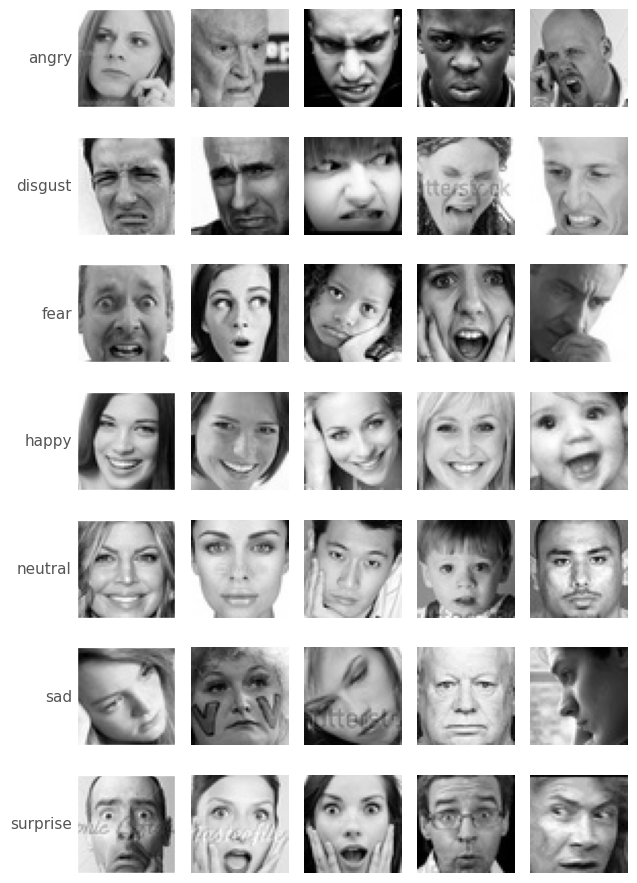

In [ ]:
show_examples(train_paths, train_labels, EMOTION_CLASSES, per_class=5, seed=SEED)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טעינת התמונות ל-tensors ועיבוד מקדים:</p>
<ul>
<li>טעינת כל התמונות מהנתיבים, כל תמונה הופכת ל-tensor בגודל (1, 48, 48) עם ערכים בטווח [0,1]</li>
<li>העברת ה-tensors ל-GPU ושמירת מטמון לטעינה מהירה בהרצות הבאות</li>
<li>נרמול על ידי חיסור תמונת הממוצע של סט האימון מכל שלושת ה-splits</li>
</ul>
</div>

In [ ]:
data_dict = load_or_build(
    '/content/data_cache.pt',
    train_paths, train_labels, val_paths, val_labels, test_paths, test_labels,
    cuda=True, flatten=False,
    drive_cache_path=os.path.join(PY_PATH, 'data_cache.pt'))

print('X_train:', data_dict['X_train'].shape)
print('X_val:  ', data_dict['X_val'].shape)
print('X_test: ', data_dict['X_test'].shape)
print('Device: ', data_dict['X_train'].device)
print('Mean after norm (~0):', data_dict['X_train'].mean().item())

Loading cache from /content/data_cache.pt ...
Cache loaded.
X_train: torch.Size([21533, 1, 48, 48])
X_val:   torch.Size([7179, 1, 48, 48])
X_test:  torch.Size([7178, 1, 48, 48])
Device:  cuda:0
Mean after norm (~0): -4.340318771056673e-09


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחשת הנרמול — חיסור תמונת הממוצע:</p>
<ul>
<li>התמונה המקורית לפני הנרמול</li>
<li>תמונת הממוצע של סט האימון, המחושבת על כל התמונות</li>
<li>התמונה לאחר חיסור הממוצע — זהו הקלט בפועל למודל</li>
</ul>
</div>

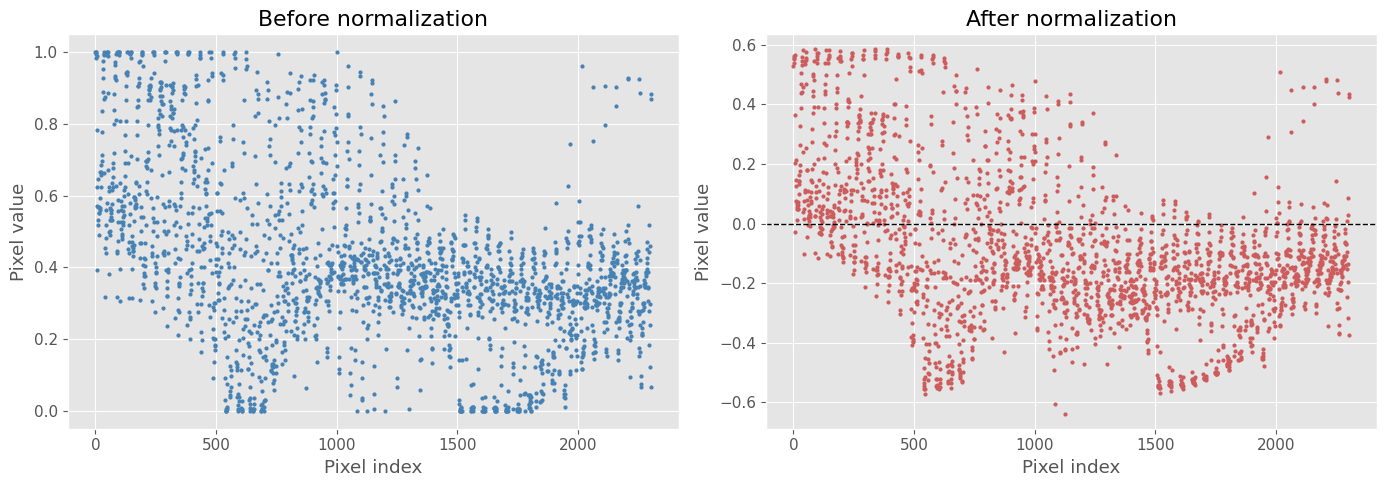

In [ ]:
mean_image = data_dict['mean_image']

img_after = data_dict['X_train'][0, 0].cpu().flatten()
img_before = img_after + mean_image[0, 0].cpu().flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(img_before, 'o', markersize=2, color='steelblue')
axes[0].set_ylim(img_before.min() - 0.05, img_before.max() + 0.05)
axes[0].set_xlabel('Pixel index')
axes[0].set_ylabel('Pixel value')
axes[0].set_title('Before normalization')

axes[1].plot(img_after, 'o', markersize=2, color='indianred')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_ylim(img_after.min() - 0.05, img_after.max() + 0.05)
axes[1].set_xlabel('Pixel index')
axes[1].set_ylabel('Pixel value')
axes[1].set_title('After normalization')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרף הנרמול:</p>
<ul>
<li>לפני הנרמול: ערכי הפיקסלים נעים בין 0 ל-1, כאשר הפיזור אינו סמטרי סביב ציר x — הערכים מרוכזים בטווח החיובי</li>
<li>אחרי הנרמול: ערכי הפיקסלים מרוכזים סביב 0 עם פיזור סמטרי, כאשר חלקם שליליים וחלקם חיוביים</li>
<li>נרמול זה מסייע לאופטימייזר להתכנס בצורה יציבה יותר, שכן כל הכניסות לרשת נמצאות בסדר גודל דומה</li>
<li>הממוצע על סט האימון לאחר הנרמול הוא כמעט 0 בדיוק (כ-4e-09), המאשר שהנרמול בוצע כראוי</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משימה 1 — מסווג SVM לינארי:</p>
<ul>
<li>אימון SVM רב-מחלקתי מאפס עם hinge loss וירידת גרדיאנט סטוכסטית</li>
<li>הנתונים משוטחים מ-(1, 48, 48) לוקטור בגודל 2304</li>
<li>חיפוש היפר-פרמטרים על גבי הוולידציה; המודל אומן עם רגולריזציית L1 (המימוש תומך גם ב-L2 וב-Elastic Net)</li>
<li>הצגת דיוק על סט המבחן ומטריצת בלבול</li>
</ul>
</div>

In [ ]:
flat = flatten_data(data_dict)
X_train_flat, X_val_flat, X_test_flat = flat['X_train'], flat['X_val'], flat['X_test']
y_train, y_val, y_test = data_dict['y_train'], data_dict['y_val'], data_dict['y_test']

print('X_train_flat:', X_train_flat.shape)
print('X_val_flat:', X_val_flat.shape)
print('X_test_flat: ', X_test_flat.shape)

X_train_flat: torch.Size([21533, 2304])
X_val_flat: torch.Size([7179, 2304])
X_test_flat:  torch.Size([7178, 2304])


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>היפר-פרמטרים של המודל — משמעות כל אחד:</p>
<ul>
<li>lr — קצב הלמידה, גודל הצעד בעדכון המשקלים</li>
<li>reg — עוצמת הרגולריזציה, מאזנת בין התאמה לנתונים לבין פשטות המודל</li>
<li>reg_type — סוג הרגולריזציה שהמימוש תומך בו: L2 (ריבועית), L1 (מוחלטת, מעודדת דלילות) או Elastic Net (שילוב של השתיים)</li>
<li>alpha — עבור Elastic Net בלבד, יחס הערבוב בין L1 ל-L2</li>
<li>batch_size — מספר הדגימות בכל צעד SGD</li>
<li>num_iters — מספר איטרציות האימון</li>
</ul>
<p>בחיפוש זה נסרקו lr, reg, batch_size ו-num_iters, ו-reg_type נקבע ל-L1. נבחר השילוב עם הדיוק הגבוה ביותר על הוולידציה.</p>
</div>

In [ ]:
param_grid_svm = {'lr': [0.009, 0.0095, 0.01],
                  'reg': [0.0009, 0.001, 0.0011],
                  'reg_type': ['l1'],
                  'batch_size': [440, 448, 456],
                  'num_iters': [3850, 3900, 3950],}

best_svm, best_params_svm, results = grid_search_svm(
    X_train_flat, y_train, X_val_flat, y_val,
    param_grid_svm, seed=SEED)

lr=0.009, reg=0.0009, reg_type=l1, batch_size=440, num_iters=3850 | train 39.20 | val 35.72
lr=0.009, reg=0.0009, reg_type=l1, batch_size=440, num_iters=3900 | train 39.56 | val 36.34
lr=0.009, reg=0.0009, reg_type=l1, batch_size=440, num_iters=3950 | train 39.73 | val 35.95
lr=0.009, reg=0.0009, reg_type=l1, batch_size=448, num_iters=3850 | train 39.24 | val 35.67
lr=0.009, reg=0.0009, reg_type=l1, batch_size=448, num_iters=3900 | train 39.51 | val 36.36
lr=0.009, reg=0.0009, reg_type=l1, batch_size=448, num_iters=3950 | train 39.73 | val 35.91
lr=0.009, reg=0.0009, reg_type=l1, batch_size=456, num_iters=3850 | train 39.20 | val 35.48
lr=0.009, reg=0.0009, reg_type=l1, batch_size=456, num_iters=3900 | train 39.60 | val 36.22
lr=0.009, reg=0.0009, reg_type=l1, batch_size=456, num_iters=3950 | train 39.73 | val 35.94
lr=0.009, reg=0.001, reg_type=l1, batch_size=440, num_iters=3850 | train 39.09 | val 35.76
lr=0.009, reg=0.001, reg_type=l1, batch_size=440, num_iters=3900 | train 39.49 | 

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תוצאות חיפוש ההיפר-פרמטרים:</p>
<ul>
<li>נבדקו קומבינציות סביב האזור הטוב ביותר — קצב למידה, רגולריזציה, גודל batch ומספר איטרציות</li>
<li>כל הקומבינציות התרכזו בטווח צר של כ-35.4 עד 36.4 אחוז על הוולידציה</li>
<li>הקומבינציה הטובה ביותר: lr=0.0095, reg=0.001, L1, batch=448, num_iters=3900 (דיוק ולידציה 36.40%)</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון מחדש של המודל הטוב ביותר והצגת גרפי האימון:</p>
<ul>
<li>אימון עם ההיפר-פרמטרים שנבחרו בחיפוש</li>
<li>הצגת ירידת ה-hinge loss וכן דיוק האימון והוולידציה לאורך האיטרציות</li>
</ul>
</div>

iteration     0 / 3900: loss 6.0000
iteration   200 / 3900: loss 4.4640
iteration   400 / 3900: loss 4.4179
iteration   600 / 3900: loss 4.2829
iteration   800 / 3900: loss 4.4939
iteration  1000 / 3900: loss 4.2806
iteration  1200 / 3900: loss 4.5050
iteration  1400 / 3900: loss 3.9115
iteration  1600 / 3900: loss 4.3792
iteration  1800 / 3900: loss 3.9775
iteration  2000 / 3900: loss 4.0434
iteration  2200 / 3900: loss 4.5747
iteration  2400 / 3900: loss 4.2794
iteration  2600 / 3900: loss 4.1648
iteration  2800 / 3900: loss 4.1583
iteration  3000 / 3900: loss 4.4263
iteration  3200 / 3900: loss 4.0733
iteration  3400 / 3900: loss 4.2425
iteration  3600 / 3900: loss 4.2151
iteration  3800 / 3900: loss 4.4443
Best params: {'lr': 0.0095, 'reg': 0.001, 'reg_type': 'l1', 'batch_size': 448, 'num_iters': 3900}

Final train accuracy: 38.59%
Final val accuracy:   35.87%


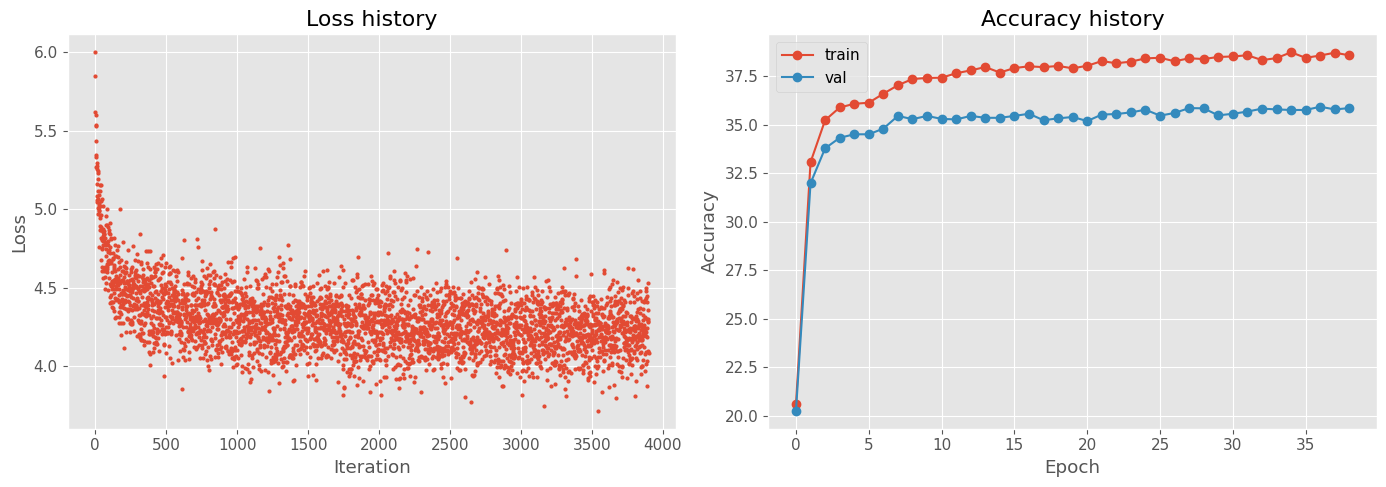

In [ ]:
best_svm = LinearSVM()
stats = best_svm.train(X_train_flat, y_train,
                       lr=best_params_svm['lr'],
                       reg=best_params_svm['reg'],
                       reg_type=best_params_svm['reg_type'],
                       batch_size=best_params_svm['batch_size'],
                       num_iters=best_params_svm['num_iters'],
                       lr_decay=0.9995,
                       X_val=X_val_flat, y_val=y_val,
                       track_every=100,
                       seed=SEED,
                       verbose=True)

print(f'Best params: {best_params_svm}')
print(f"\nFinal train accuracy: {stats['train_acc_history'][-1]:.2f}%")
print(f"Final val accuracy:   {stats['val_acc_history'][-1]:.2f}%")

plot_stats(stats)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרפי האימון:</p>
<ul>
<li>גרף ה-loss: ההפסד צונח במהירות מ-6 לכ-4.3 בכ-200 האיטרציות הראשונות, ואז מתייצב סביב 4.2-4.3 עם תנודתיות האופיינית לירידת גרדיאנט סטוכסטית</li>
<li>גרף ה-accuracy: דיוק האימון והוולידציה עולים יחד במהירות ומתייצבים — האימון סביב 38.6 אחוז והוולידציה סביב 35.8 אחוז</li>
<li>שתי העקומות מגיעות למישור (plateau) כבר לאחר מספר מאות איטרציות, מה שמראה שהמודל מיצה את יכולתו ושאיטרציות נוספות אינן משפרות</li>
<li>הפער הקטן בין האימון לוולידציה מאשר שאין overfitting משמעותי — המגבלה היא לינארית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכת המודל הטוב ביותר על סט המבחן:</p>
<ul>
<li>חישוב הדיוק על סט המבחן עבור המודל שנבחר בחיפוש</li>
<li>הצגת מטריצת בלבול מנורמלת לבחינת הביצועים לפי קטגוריה</li>
</ul>
</div>

Best params: {'lr': 0.0095, 'reg': 0.001, 'reg_type': 'l1', 'batch_size': 448, 'num_iters': 3900}
Train accuracy: 38.68%
Val accuracy:   35.85%
Test accuracy:  37.32%

--- Confusion Matrix (Text Table) ---
True \ Pred         angry   disgust      fear     happy   neutral       sad  surprise
-------------------------------------------------------------------------------------
angry                0.17      0.00      0.09      0.26      0.15      0.19      0.13
disgust              0.19      0.05      0.14      0.21      0.15      0.14      0.14
fear                 0.10      0.01      0.14      0.19      0.17      0.17      0.23
happy                0.06      0.00      0.05      0.58      0.11      0.10      0.09
neutral              0.08      0.01      0.07      0.17      0.38      0.17      0.13
sad                  0.13      0.01      0.08      0.17      0.19      0.31      0.11
surprise             0.04      0.00      0.07      0.11      0.10      0.08      0.58
--------------------

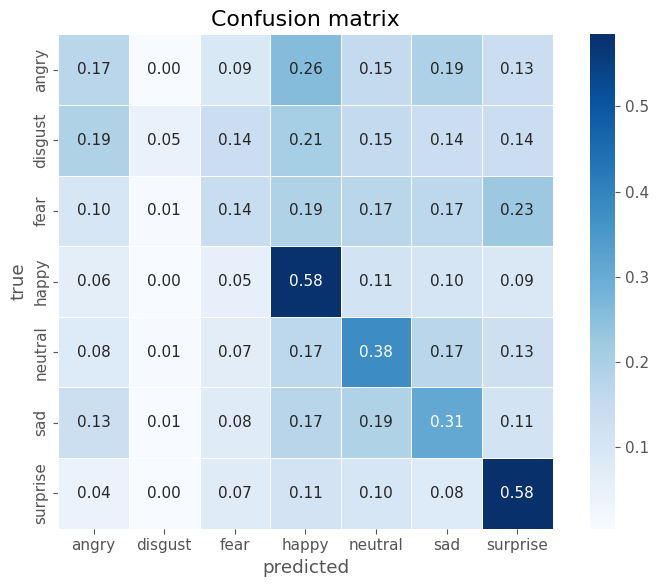

In [ ]:
train_acc_svm = accuracy(best_svm, X_train_flat, y_train)
val_acc_svm   = accuracy(best_svm, X_val_flat, y_val)
test_acc_svm  = accuracy(best_svm, X_test_flat, y_test)

print(f'Best params: {best_params_svm}')
print(f'Train accuracy: {train_acc_svm:.2f}%')
print(f'Val accuracy:   {val_acc_svm:.2f}%')
print(f'Test accuracy:  {test_acc_svm:.2f}%')

results_svm = {'name': 'Linear SVM', 'params': best_params_svm,
               'train_acc': train_acc_svm, 'val_acc': val_acc_svm, 'test_acc': test_acc_svm}

y_pred_svm = best_svm.predict(X_test_flat)

print_confusion_matrix(y_test.cpu(), y_pred_svm.cpu(), EMOTION_CLASSES, normalize=True)
plot_confusion_matrix(y_test.cpu(), y_pred_svm.cpu(), EMOTION_CLASSES, normalize=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבלבול וסיכום משימה 1:</p>
<ul>
<li>הדיוק הסופי: 38.68 אחוז על האימון, 35.85 אחוז על הוולידציה ו-37.32 אחוז על המבחן</li>
<li>happy ו-surprise זוהו הכי טוב (58 אחוז כל אחת) — אלו רגשות עם הבעות פנים בולטות וברורות</li>
<li>disgust כמעט לא זוהתה (5 אחוז) — הדיוק הנמוך ביותר מכל המחלקות, בעיקר בגלל מיעוט הדגימות בקטגוריה זו</li>
<li>מבין הקטגוריות המיוצגות היטב, fear היא הקשה ביותר (14 אחוז), ומתפזרת בעיקר ל-surprise, happy, neutral ו-sad</li>
<li>הרבה טעויות מתנקזות ל-happy ול-neutral, שהן הקטגוריות הגדולות — המודל הלינארי נוטה לכיוון הקטגוריות השכיחות</li>
<li>הפער הקטן בין האימון לוולידציה מאשר שהמגבלה אינה overfitting אלא חוסר היכולת של מודל לינארי ללכוד את המורכבות של זיהוי רגשות, ומכאן המעבר לרשתות קונבולוציה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משימה 2 — רשת קונבולוציה פשוטה:</p>
<ul>
<li>שתי שכבות קונבולוציה בסיסיות, כל אחת בנויה מ-Conv, ReLU ו-MaxPool</li>
<li>בראש הרשת שכבה מלאה אחת לסיווג ל-7 הקטגוריות</li>
<li>ללא BatchNorm, Dropout או טכניקות נוספות — זהו ה-baseline שהרשת העמוקה במשימה 3 תשפר</li>
<li>אימון עם Adam והצגת גרפים של loss ו-accuracy</li>
</ul>
<p>מבנה הרשת (עם הפרמטרים שנבחרו בחיפוש: conv1=64, conv2=72):</p>
<ul dir="ltr" align="left">
<li>Input (1, 48, 48)</li>
<li>Conv(1→64, 3×3) → ReLU → MaxPool → (64, 24, 24)</li>
<li>Conv(64→72, 3×3) → ReLU → MaxPool → (72, 12, 12)</li>
<li>Flatten → Linear(10368→7)</li>
<li>Output (7)</li>
</ul>
</div>

In [ ]:
X_train = data_dict['X_train']
X_val   = data_dict['X_val']
X_test  = data_dict['X_test']
y_train = data_dict['y_train']
y_val   = data_dict['y_val']
y_test  = data_dict['y_test']

print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', X_test.shape)

X_train: torch.Size([21533, 1, 48, 48])
X_val  : torch.Size([7179, 1, 48, 48])
X_test : torch.Size([7178, 1, 48, 48])


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיפוש היפר-פרמטרים בשני שלבים:</p>
<ul>
<li>שלב א — חיפוש רחב: סריקת מספר הפילטרים (conv1, conv2) וקצב הלמידה (lr) על פני 27 קומבינציות, שאר הפרמטרים קבועים</li>
<li>שלב ב — כיוונון עדין: קיבוע הפרמטרים הטובים משלב א וסריקת:
  <ul>
    <li>weight_decay — עוצמת רגולריזציית L2, מונעת overfitting</li>
    <li>batch_size — מספר הדגימות בכל צעד אימון</li>
    <li>lr_decay — קצב דעיכת קצב הלמידה בין epochs</li>
  </ul>
</li>
<li>בכל שלב נבחר השילוב עם דיוק הולידציה הגבוה ביותר; כל קומבינציה מאומנת ל-5 epochs</li>
</ul>
</div>

In [ ]:
param_grid_simple_cnn_a = {'conv1':        [56, 64, 72],
                           'conv2':        [72 , 80, 88],
                           'lr':           [2e-3, 1e-3, 9e-4],
                           'weight_decay': [3e-05],
                           'batch_size':   [48],
                           'lr_decay':     [0.93],
                           'num_epochs':   [5]}

_, best_params_a, results_a = grid_search_cnn(
    X_train, y_train, X_val, y_val, param_grid_simple_cnn_a, seed=SEED)

print(f"\n[grid a] best params found: {best_params_a}")

conv1=56, conv2=72, lr=0.002, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 43.24
conv1=56, conv2=72, lr=0.001, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.83
conv1=56, conv2=72, lr=0.0009, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.37
conv1=56, conv2=80, lr=0.002, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 44.17
conv1=56, conv2=80, lr=0.001, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.05
conv1=56, conv2=80, lr=0.0009, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.95
conv1=56, conv2=88, lr=0.002, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 45.06
conv1=56, conv2=88, lr=0.001, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.89
conv1=56, conv2=88, lr=0.0009, weight_decay=3e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 47.72
conv1=64, conv2=72, lr=0.002, weight_decay=3e-05, ba

In [ ]:
param_grid_simple_cnn_b = {'conv1':        [best_params_a['conv1']],
                           'conv2':        [best_params_a['conv2']],
                           'lr':           [best_params_a['lr']],
                           'weight_decay': [4e-5, 3e-5, 2e-5],
                           'batch_size':   [44, 48, 52],
                           'lr_decay':     [0.94, 0.93, 0.92],
                           'num_epochs':   [5]}

_, best_params_b, results_b = grid_search_cnn(
    X_train, y_train, X_val, y_val, param_grid_simple_cnn_b, seed=SEED)

print(f"\n[grid b] final best params found: {best_params_b}")

conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=44, lr_decay=0.94, num_epochs=5 | val 48.32
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=44, lr_decay=0.93, num_epochs=5 | val 48.43
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=44, lr_decay=0.92, num_epochs=5 | val 48.02
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=48, lr_decay=0.94, num_epochs=5 | val 49.10
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=48, lr_decay=0.93, num_epochs=5 | val 49.16
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=48, lr_decay=0.92, num_epochs=5 | val 49.27
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=52, lr_decay=0.94, num_epochs=5 | val 47.93
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=52, lr_decay=0.93, num_epochs=5 | val 47.57
conv1=64, conv2=72, lr=0.0009, weight_decay=4e-05, batch_size=52, lr_decay=0.92, num_epochs=5 | val 48.11
conv1=64, conv2=72, lr=0.0009, weight_decay=3e

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תוצאות חיפוש ההיפר-פרמטרים:</p>
<ul>
<li>הפרמטרים הטובים ביותר: conv1=64, conv2=72, lr=0.0009, weight_decay=2e-05, batch_size=48, lr_decay=0.94 (דיוק ולידציה 49.81 אחוז)</li>
<li>conv1=64 עקף את conv1=72 ו-conv1=56 — יותר פילטרים בשכבה הראשונה לא שיפרו; conv2=72 נתן את האיזון הטוב ביותר (טוב יותר מ-80 ו-88)</li>
<li>lr=0.002 היה גבוה מדי ויצר אי-יציבות באופן עקבי; lr=0.0009 השיג את ההתכנסות הטובה ביותר</li>
<li>batch_size=52 פגע בדיוק; batch=48 היה העקבי ביותר</li>
<li>weight_decay=2e-05 ו-lr_decay=0.94 נתנו את הדיוק הגבוה ביותר על הוולידציה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון סופי של ה-baseline — מאמנים את הצירוף הטוב ביותר ושומרים את המשקלים עם דיוק הולידציה הגבוה ביותר. מציגים את גרפי ה-loss וה-accuracy. ניתן לראות overfitting ברור: דיוק האימון ממשיך לעלות בעוד דיוק הולידציה מתייצב סביב 51 אחוז.</p>
</div>

Epoch   1/30 | loss: 1.6284 | train: 44.54% | val: 43.00%  <- NEW BEST
Epoch   2/30 | loss: 1.4275 | train: 49.75% | val: 46.50%  <- NEW BEST
Epoch   3/30 | loss: 1.3361 | train: 53.08% | val: 48.80%  <- NEW BEST
Epoch   4/30 | loss: 1.2672 | train: 55.26% | val: 49.19%  <- NEW BEST
Epoch   5/30 | loss: 1.2111 | train: 57.86% | val: 49.81%  <- NEW BEST
Epoch   6/30 | loss: 1.1583 | train: 59.02% | val: 50.38%  <- NEW BEST
Epoch   7/30 | loss: 1.1171 | train: 61.23% | val: 50.15%
Epoch   8/30 | loss: 1.0783 | train: 63.29% | val: 50.54%  <- NEW BEST
Epoch   9/30 | loss: 1.0425 | train: 64.34% | val: 50.36%
Epoch  10/30 | loss: 1.0128 | train: 66.13% | val: 50.54%
Epoch  11/30 | loss: 0.9768 | train: 67.38% | val: 50.19%
Epoch  12/30 | loss: 0.9477 | train: 68.25% | val: 50.61%  <- NEW BEST
Epoch  13/30 | loss: 0.9254 | train: 68.94% | val: 50.06%
Epoch  14/30 | loss: 0.8978 | train: 69.06% | val: 50.69%  <- NEW BEST
Epoch  15/30 | loss: 0.8777 | train: 70.61% | val: 50.56%
Epoch  16/30 

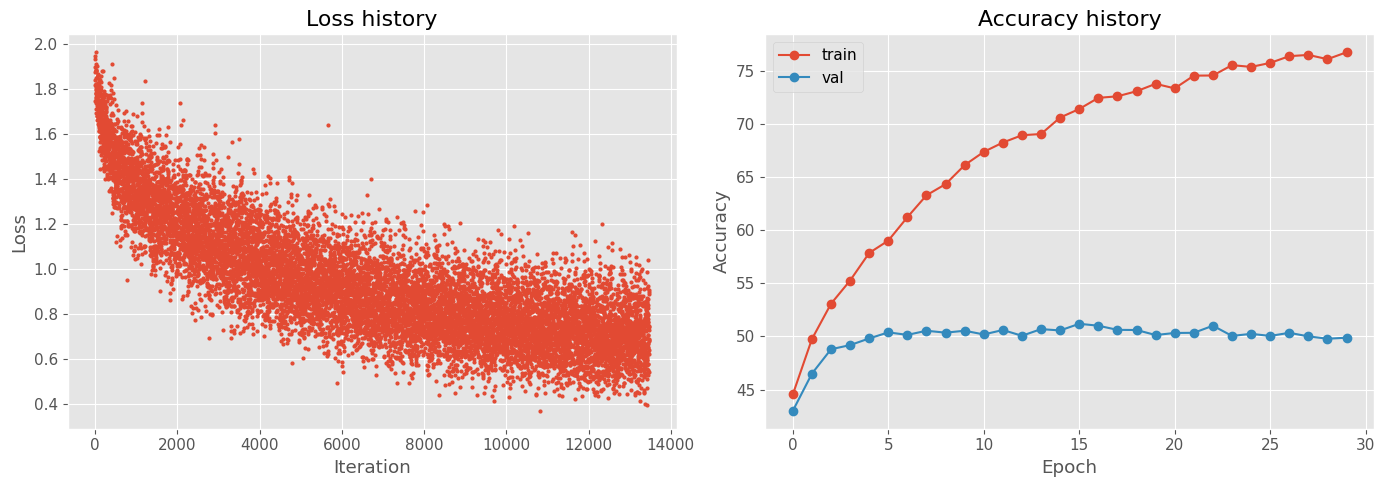

In [ ]:
model_simple_cnn = SimpleCNN(conv1=best_params_b['conv1'], conv2=best_params_b['conv2'])

stats = train_cnn(model_simple_cnn, X_train, y_train, X_val, y_val,
                  lr=best_params_b['lr'],
                  weight_decay=best_params_b['weight_decay'],
                  batch_size=best_params_b['batch_size'],
                  num_epochs=30,
                  lr_decay=best_params_b['lr_decay'],
                  seed=SEED, verbose=True)

print(f"\nBest val: {stats['best_val_acc']:.2f}% at epoch {stats['best_epoch']}")
plot_stats(stats)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרפי האימון:</p>
<ul>
<li>גרף ה-loss: ההפסד יורד בהתמדה מ-כ-1.6 לכ-0.7 לאורך 30 ה-epochs, בלי מישור — בניגוד ל-SVM, הרשת ממשיכה "ללמוד" (למעשה לשנן) את האימון ככל שמתקדמים</li>
<li>גרף ה-accuracy: דיוק האימון מטפס ברציפות לכ-77 אחוז, בעוד דיוק הוולידציה עולה רק עד 51.19 אחוז (epoch 16) ואז מתייצב סביב 50-51 אחוז</li>
<li>הפער ההולך וגדל בין האימון לוולידציה הוא overfitting מובהק — צפוי, שכן זהו baseline כמעט ללא רגולריזציה: הרגולריזציה היחידה היא weight_decay זעיר, ללא BatchNorm, Dropout או augmentation</li>
<li>שמירת ה-best-val snapshot מבטיחה שהמודל המדווח הוא בעל הוולידציה הטובה ביותר (51.19 אחוז) ולא המודל המאומן-יתר מהאפוקים המאוחרים</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה — מודדים את דיוק ה-baseline על אימון, ולידציה ומבחן, שומרים את התוצאות להשוואה ומציגים את מטריצת הבלבול. הקטגוריות happy ו-surprise מזוהות הכי טוב, ו-fear ו-disgust הכי קשות.</p>
</div>

Best params: {'conv1': 64, 'conv2': 72, 'lr': 0.0009, 'weight_decay': 2e-05, 'batch_size': 48, 'lr_decay': 0.94, 'num_epochs': 5}
Train accuracy: 71.41%
Val accuracy:   51.19%
Test accuracy:  50.77%

--- Confusion Matrix (Text Table) ---
True \ Pred         angry   disgust      fear     happy   neutral       sad  surprise
-------------------------------------------------------------------------------------
angry                0.37      0.01      0.08      0.14      0.18      0.16      0.06
disgust              0.22      0.37      0.14      0.07      0.09      0.11      0.01
fear                 0.12      0.01      0.27      0.13      0.14      0.20      0.13
happy                0.04      0.00      0.03      0.76      0.09      0.05      0.03
neutral              0.08      0.00      0.06      0.16      0.50      0.16      0.03
sad                  0.12      0.01      0.11      0.15      0.22      0.36      0.04
surprise             0.05      0.00      0.10      0.07      0.06      0.0

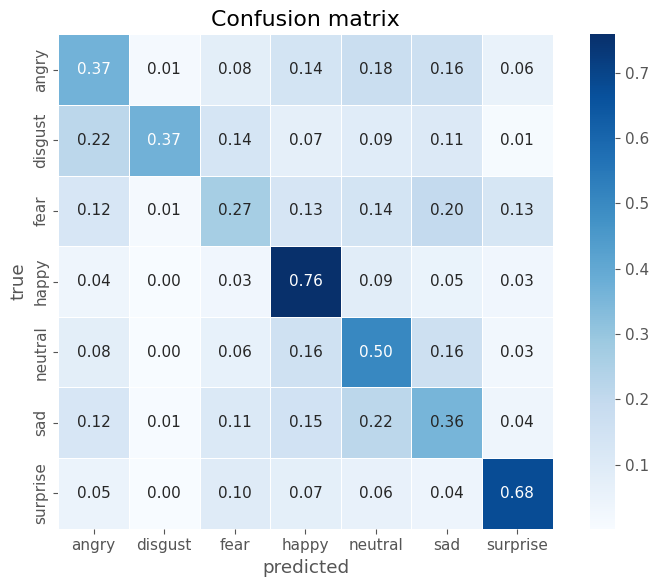

In [ ]:
train_acc_s, _ = evaluate(model_simple_cnn, X_train, y_train)
val_acc_s, _   = evaluate(model_simple_cnn, X_val, y_val)
test_acc_s, y_pred_s = evaluate(model_simple_cnn, X_test, y_test)

print(f'Best params: {best_params_b}')
print(f'Train accuracy: {train_acc_s*100:.2f}%')
print(f'Val accuracy:   {val_acc_s*100:.2f}%')
print(f'Test accuracy:  {test_acc_s*100:.2f}%')

results_2layer = {'name': 'Simple CNN (2 layers)', 'params': best_params_b,
                  'train_acc': train_acc_s*100, 'val_acc': val_acc_s*100, 'test_acc': test_acc_s*100}

print_confusion_matrix(y_test.cpu(), y_pred_s, EMOTION_CLASSES, normalize=True)
plot_confusion_matrix(y_test.cpu(), y_pred_s, EMOTION_CLASSES, normalize=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבלבול וסיכום משימה 2:</p>
<ul>
<li>הדיוק הסופי: 71.41 אחוז על האימון (ב-best-val snapshot), 51.19 אחוז על הוולידציה ו-50.77 אחוז על המבחן</li>
<li>happy (76 אחוז) ו-surprise (68 אחוז) זוהו הכי טוב — רגשות עם הבעות בולטות וברורות</li>
<li>fear (27 אחוז) הקשה ביותר ומתבלבלת בעיקר עם sad (20 אחוז); disgust (37 אחוז) עדיין חלשה</li>
<li>שיפור דרמטי לעומת ה-SVM: disgust עלתה מ-5 אחוז ל-37 אחוז, והדיוק הכולל קפץ מ-37 אחוז לכ-51 אחוז — הקונבולוציות לוכדות מבנה מרחבי שהמודל הלינארי לא מסוגל ללכוד</li>
<li>עם זאת, הפער הגדול בין האימון (71 אחוז) למבחן (51 אחוז) מצביע על overfitting משמעותי — תוצאה ישירה של רגולריזציה מינימלית (רק weight_decay זעיר, ללא BatchNorm, Dropout או augmentation). זו בדיוק המוטיבציה לרשת העמוקה במשימה 3, שמוסיפה BatchNorm, Dropout, augmentation ושקלול מחלקות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משימה 3 — רשת קונבולוציה עמוקה:</p>
<ul>
<li>חמש שכבות קונבולוציה, כל אחת בנויה מ-Conv, BatchNorm, GELU ו-MaxPool</li>
<li>בראש הרשת Global Average Pooling, שכבה מלאה עם BatchNorm ו-Dropout, ואז שכבת סיווג ל-7 הקטגוריות</li>
<li>הוספת רגולריזציה (BatchNorm, Dropout, weight decay) והגדלת הנתונים (augmentation) כדי לשבור את ה-overfitting שראינו ב-baseline</li>
<li>שקלול מחלקות (class weights) ב-loss כדי לפצות על חוסר האיזון החמור — במיוחד disgust שמהווה כ-1.5% מסט האימון</li>
<li>אימון עם AdamW, הפחתת קצב למידה הדרגתית, שמירת המשקלים הטובים ביותר ועצירה מוקדמת</li>
</ul>
<p>הטכניקות שנוספו מעבר ל-baseline ומדוע:</p>
<ul>
<li>BatchNorm — מנרמל את הפעילויות בכל שכבה, מייצב ומאיץ את האימון</li>
<li>GELU — פונקציית אקטיבציה חלקה יותר מ-ReLU, מתאימה לרשתות עמוקות</li>
<li>Dropout — מכבה נוירונים אקראית בשכבה המלאה ומונע שינון של האימון</li>
<li>weight decay — ענישה על משקלים גדולים, רגולריזציה נוספת</li>
<li>augmentation — היפוך אופקי, סיבוב קל והזזה אקראית על כל batch, מרחיב את מגוון האימון ומפחית overfitting</li>
<li>class weights — שקלול ה-loss הפוך לתדירות כל מחלקה, כך שהרשת לא תזניח מחלקות נדירות</li>
</ul>
<p>מבנה הרשת (עם הפרמטרים שנבחרו בחיפוש):</p>
<ul dir="ltr" align="left">
<li>Input (1, 48, 48)</li>
<li>Conv(1→28, 3×3) → BatchNorm → GELU → MaxPool → (28, 24, 24)</li>
<li>Conv(28→144, 3×3) → BatchNorm → GELU → MaxPool → (144, 12, 12)</li>
<li>Conv(144→124, 3×3) → BatchNorm → GELU → MaxPool → (124, 6, 6)</li>
<li>Conv(124→188, 3×3) → BatchNorm → GELU → MaxPool → (188, 3, 3)</li>
<li>Conv(188→152, 3×3) → BatchNorm → GELU → MaxPool → (152, 1, 1)</li>
<li>GAP → Linear(152→384) → BatchNorm → GELU → Dropout → Linear(384→7)</li>
<li>Output (7)</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שולפים את הטנסורים מתוך data_dict ומריצים batch דמה דרך הרשת כדי לוודא שהפלט בגודל הנכון (7 קטגוריות) וסופרים את מספר הפרמטרים. הנתונים כבר על ה-GPU, כך שהאימון וההגדלה (augmentation) רצים כולם על ה-GPU.</p>
<p>בנוסף, מחשבים את משקלי המחלקות (class weights) מתוך התפלגות סט האימון בלבד — ההפך מתדירות כל מחלקה — כדי לפצות על חוסר האיזון החמור בעת האימון. המשקלים מועברים אחר כך ל-loss בתא האימון.</p>
</div>

In [ ]:
X_train = data_dict['X_train'].float(); y_train = data_dict['y_train']
X_val   = data_dict['X_val'].float();   y_val   = data_dict['y_val']
X_test  = data_dict['X_test'].float();  y_test  = data_dict['y_test']
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

_m = DeepCNN().to(device)
_dummy = torch.randn(4, 1, 48, 48).to(device)
print('Output shape:', _m(_dummy).shape)
print('Parameters: ', count_parameters(_m))
del _m, _dummy

counts = torch.bincount(y_train, minlength=7).float()
class_weights = counts.sum() / (len(counts) * counts)
print('class weights:', class_weights.detach().cpu().numpy().round(2))

Train: torch.Size([21533, 1, 48, 48]) | Val: torch.Size([7179, 1, 48, 48]) | Test: torch.Size([7178, 1, 48, 48])
Output shape: torch.Size([4, 7])
Parameters:  1378727
class weights: [1.03 9.41 1.   0.57 0.83 0.85 1.29]


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדלת הנתונים (augmentation) — מבוצעת ישירות על ה-GPU על כל batch, כך שכל תמונה עוברת שינוי אקראי משלה בכל epoch. הרשת רואה גרסה מעט שונה בכל פעם ולומדת תכונות כלליות במקום לשנן:</p>
<ul>
<li>היפוך אופקי בהסתברות חצי — פנים פחות או יותר סימטריות</li>
<li>סיבוב אקראי עד 10 מעלות — להתמודדות עם פנים מעט מוטות</li>
<li>הזזה אקראית של מספר פיקסלים — להתמודדות עם פנים שאינן ממורכזות</li>
<li>לא משתמשים בהיפוך אנכי או בסיבוב גדול כי פנים הפוכות אינן הגיוניות</li>
</ul>
<p>ההגדלה מובנית בתוך פונקציית האימון (augment=True), ללא צורך ב-DataLoader.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיפוש היפר-פרמטרים בשיטה משורשרת (chained grid) — במקום לבדוק את כל הצירופים יחד, מחלקים את החיפוש לארבעה שלבים. בכל שלב בודקים קבוצת פרמטרים ומקבעים את הטובים לשלב הבא. כל צירוף מאומן 5 epochs בלבד, והבחירה לפי דיוק הולידציה:</p>
<ul>
<li>שלב א — conv1–conv4 (מספר הפילטרים בשכבות הקונבולוציה, קובע את עומק הייצוג שהרשת לומדת בכל שכבה)</li>
<li>שלב ב — conv5 (פילטרים בשכבה האחרונה), hidden_dim (גודל השכבה המלאה, קובע את כוח הייצוג לפני הסיווג) ו-dropout (שיעור הכיבוי האקראי של נוירונים, מאזן בין קיבולת לרגולריזציה)</li>
<li>שלב ג — kernel_size (גודל חלון הקונבולוציה, משפיע על גודל השדה הקולט), stride (גודל הצעד בין חלונות, משפיע על רזולוציית הפיצ'רים) ו-weight_decay (עוצמת רגולריזציית L2, מונע משקלים גדולים מדי)</li>
<li>שלב ד — lr (קצב הלמידה), lr_decay (דעיכת קצב הלמידה בין epochs) ו-batch_size (מספר הדגימות בכל צעד אימון), שלושת הפרמטרים שמשפיעים ישירות על דינמיקת ההתכנסות</li>
</ul>
</div>

In [ ]:
param_grid_deep_cnn_a = {'conv1':        [24, 28, 32],
                         'conv2':        [136, 144, 152],
                         'conv3':        [124, 128, 132],
                         'conv4':        [188, 192, 196],
                         'conv5':        [152],
                         'hidden_dim':   [384],
                         'dropout':      [0.4],
                         'kernel_size':  [3],
                         'stride':       [1],
                         'lr':           [7e-4],
                         'weight_decay': [4e-4],
                         'lr_decay':     [0.92],
                         'batch_size':   [160],}

_, best_a, results_a = grid_search_deep_cnn(
    X_train, y_train, X_val, y_val, param_grid_deep_cnn_a,
    num_epochs=5, augment=True, seed=SEED)
print('best a:', best_a)

conv1=24, conv2=136, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.51
conv1=24, conv2=136, conv3=124, conv4=192, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 55.61
conv1=24, conv2=136, conv3=124, conv4=196, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 56.89
conv1=24, conv2=136, conv3=128, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 56.23
conv1=24, conv2=136, conv3=128, conv4=192, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 56.97
conv1=24, conv2=136, conv3=128, conv4=196, conv5=152, hidden_dim=384, dropout=0.4, kernel_

In [ ]:
param_grid_deep_cnn_b = {'conv1':        [best_a['conv1']],
                         'conv2':        [best_a['conv2']],
                         'conv3':        [best_a['conv3']],
                         'conv4':        [best_a['conv4']],
                         'conv5':        [148, 152, 156],
                         'hidden_dim':   [352, 384, 416],
                         'dropout':      [0.35, 0.4, 0.45],
                         'kernel_size':  [3],
                         'stride':       [1],
                         'lr':           [7e-4],
                         'weight_decay': [4e-4],
                         'lr_decay':     [0.92],
                         'batch_size':   [160],}

_, best_b, results_b = grid_search_deep_cnn(
    X_train, y_train, X_val, y_val, param_grid_deep_cnn_b,
    num_epochs=5, augment=True, seed=SEED)
print('best b:', best_b)

conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=352, dropout=0.35, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.38
conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=352, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 56.22
conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=352, dropout=0.45, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.08
conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=384, dropout=0.35, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.46
conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.49
conv1=28, conv2=144, conv3=124, conv4=188, conv5=148, hidden_dim=384, dropout=0.45, ker

In [ ]:
param_grid_deep_cnn_c = {'conv1':        [best_b['conv1']],
                         'conv2':        [best_b['conv2']],
                         'conv3':        [best_b['conv3']],
                         'conv4':        [best_b['conv4']],
                         'conv5':        [best_b['conv5']],
                         'hidden_dim':   [best_b['hidden_dim']],
                         'dropout':      [best_b['dropout']],
                         'kernel_size':  [2, 3, 4],
                         'stride':       [1, 2, 3],
                         'lr':           [7e-4],
                         'weight_decay': [3e-4, 4e-4 ,5e-4],
                         'lr_decay':     [0.92],
                         'batch_size':   [160],}

best_model_deep, best_c, results_c = grid_search_deep_cnn(
    X_train, y_train, X_val, y_val, param_grid_deep_cnn_c,
    num_epochs=5, augment=True, seed=SEED)
print('best c:', best_c)

conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=2, stride=1, lr=0.0007, weight_decay=0.0003, lr_decay=0.92, batch_size=160 | val 54.09
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=2, stride=1, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 54.05
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=2, stride=1, lr=0.0007, weight_decay=0.0005, lr_decay=0.92, batch_size=160 | val 53.96
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=2, stride=2, lr=0.0007, weight_decay=0.0003, lr_decay=0.92, batch_size=160 | val 44.94
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=2, stride=2, lr=0.0007, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 44.50
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_

In [ ]:
param_grid_deep_cnn_d = {'conv1':        [best_c['conv1']],
                         'conv2':        [best_c['conv2']],
                         'conv3':        [best_c['conv3']],
                         'conv4':        [best_c['conv4']],
                         'conv5':        [best_c['conv5']],
                         'hidden_dim':   [best_c['hidden_dim']],
                         'dropout':      [best_c['dropout']],
                         'kernel_size':  [best_c['kernel_size']],
                         'stride':       [best_c['stride']],
                         'lr':           [6e-4, 7e-4, 8e-4],
                         'weight_decay': [best_c['weight_decay']],
                         'lr_decay':     [0.91, 0.92, 0.93],
                         'batch_size':   [152 ,160, 168],}

best_model_deep_d, best_d, results_d = grid_search_deep_cnn(
    X_train, y_train, X_val, y_val, param_grid_deep_cnn_d,
    num_epochs=5, augment=True, seed=SEED)

print('best d:', best_d)

conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0006, weight_decay=0.0004, lr_decay=0.91, batch_size=152 | val 57.22
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0006, weight_decay=0.0004, lr_decay=0.91, batch_size=160 | val 57.58
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0006, weight_decay=0.0004, lr_decay=0.91, batch_size=168 | val 55.44
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0006, weight_decay=0.0004, lr_decay=0.92, batch_size=152 | val 56.44
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0006, weight_decay=0.0004, lr_decay=0.92, batch_size=160 | val 57.70
conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>תוצאות חיפוש ההיפר-פרמטרים:</p>
<ul>
<li>הפרמטרים הטובים ביותר: conv1=28, conv2=144, conv3=124, conv4=188, conv5=152, hidden_dim=384, dropout=0.4, kernel_size=3, stride=1, lr=0.0007, weight_decay=4e-4, lr_decay=0.92, batch_size=160 (דיוק ולידציה 58.35 אחוז)</li>
<li>שלב א: conv1=28 נתן את האיזון הטוב ביותר — conv1=24 קטן מדי, conv1=32 קרוב אך נופל; conv4=188 עקף את 192 ו-196</li>
<li>שלב ב: conv5=152, hidden_dim=384 ו-dropout=0.4 שמרו על התוצאה מהשלב הקודם — שינוי הערכים לא שיפר, מה שמעיד שהמבנה כבר אופטימלי</li>
<li>שלב ג: kernel_size=3 עם stride=1 הכריעו בבירור — stride גדול מ-1 פגע קשות בדיוק (stride=2 הוריד ל-~51 אחוז, stride=3 ל-~45 אחוז), kernel_size=2 ו-4 נחותים מ-3</li>
<li>שלב ד: lr=0.0007 ו-lr_decay=0.92 עם batch_size=160 אישרו את הפרמטרים — שינויים קטנים ב-lr וב-batch_size לא שיפרו את התוצאה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון מלא של המודל הטוב ביותר — מאמנים את הצירוף הסופי עד הסוף:</p>
<ul>
<li>ה-loss משוקלל לפי תדירות המחלקות (class weights שחושבו על סט האימון בלבד) כדי לפצות על חוסר האיזון</li>
<li>מספר epochs גדול (100) עם עצירה מוקדמת — אם הדיוק על הולידציה לא משתפר 20 epochs רצופים, האימון נעצר</li>
<li>שמירת המשקלים של ה-epoch עם הולידציה הטובה ביותר והחזרתם בסוף האימון</li>
<li>הצגת גרפי loss ו-accuracy לאורך האימון</li>
</ul>
</div>

Epoch   1/100 | loss: 1.8536 | train: 35.84% | val: 37.11%  <- NEW BEST
Epoch   2/100 | loss: 1.6010 | train: 33.95% | val: 33.99%
Epoch   3/100 | loss: 1.4523 | train: 48.78% | val: 47.82%  <- NEW BEST
Epoch   4/100 | loss: 1.3575 | train: 50.81% | val: 48.75%  <- NEW BEST
Epoch   5/100 | loss: 1.2809 | train: 53.16% | val: 51.11%  <- NEW BEST
Epoch   6/100 | loss: 1.2354 | train: 56.46% | val: 54.12%  <- NEW BEST
Epoch   7/100 | loss: 1.1978 | train: 55.57% | val: 52.85%
Epoch   8/100 | loss: 1.1565 | train: 59.82% | val: 57.26%  <- NEW BEST
Epoch   9/100 | loss: 1.1249 | train: 60.55% | val: 56.73%
Epoch  10/100 | loss: 1.1007 | train: 59.32% | val: 54.98%
Epoch  11/100 | loss: 1.0679 | train: 60.81% | val: 56.19%
Epoch  12/100 | loss: 1.0444 | train: 61.06% | val: 56.41%
Epoch  13/100 | loss: 1.0196 | train: 62.68% | val: 57.53%  <- NEW BEST
Epoch  14/100 | loss: 0.9931 | train: 61.34% | val: 56.21%
Epoch  15/100 | loss: 0.9682 | train: 65.62% | val: 59.70%  <- NEW BEST
Epoch  16/1

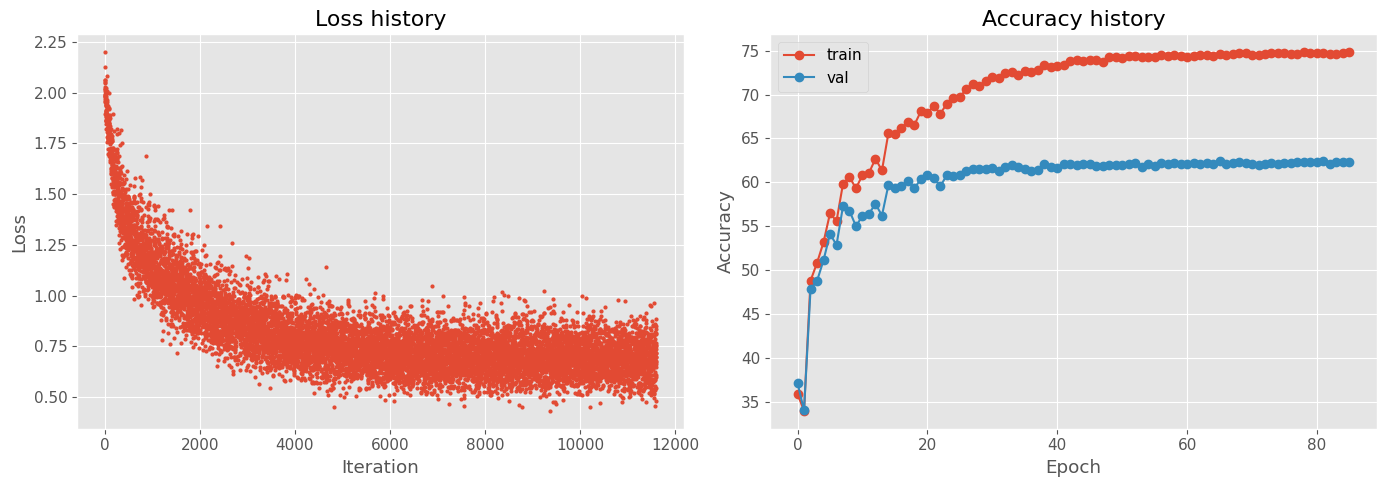

In [ ]:
model_deep_cnn = DeepCNN(conv1=best_d['conv1'], conv2=best_d['conv2'], conv3=best_d['conv3'], conv4=best_d['conv4'], conv5=best_d['conv5'],
                         hidden_dim=best_d['hidden_dim'], dropout=best_d['dropout'], kernel_size=best_d['kernel_size'], stride=best_d['stride'])

stats = train_deep_cnn(model_deep_cnn, X_train, y_train, X_val, y_val,
                       lr=best_d['lr'],
                       weight_decay=best_d['weight_decay'],
                       batch_size=best_d['batch_size'],
                       lr_decay=best_d['lr_decay'],
                       num_epochs=100, augment=True, patience=20,
                       seed=SEED, verbose=True, class_weights=class_weights)

print(f"\nBest val: {stats['best_val_acc']:.2f}% at epoch {stats['best_epoch']}")
plot_stats(stats)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרפי האימון:</p>
<ul>
<li>גרף ה-loss: יורד בהתמדה מ-כ-1.85 לכ-0.7 ומתייצב — בניגוד ל-baseline, הירידה מאטה ומשתטחת במקום להמשיך ולרדת, סימן שהרגולריזציה עובדת</li>
<li>גרף ה-accuracy: דיוק האימון מתייצב סביב 74-75 אחוז ודיוק הולידציה מתכנס אליו ומתייצב סביב 62 אחוז — הפער בין האימון לולידציה (~12 אחוז) קטן בהרבה לעומת ה-baseline (~20 אחוז)</li>
<li>העצירה המוקדמת פעלה ב-epoch 86 — הרשת לא שיפרה את הולידציה 20 epochs רצופים לאחר epoch 66; המשקלים של epoch 66 (62.39 אחוז) הוחזרו</li>
<li>עקומת הולידציה עולה בצורה חלקה ויציבה עד epoch ~40, ולאחר מכן מתכנסת לפלטו עם שיפורים זעירים עד epoch 66 — האימון והולידציה רצים במקביל, ללא overfitting חריף</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה סופית — בודקים את המודל הסופי על שלוש הקבוצות, שומרים את התוצאות להשוואה בין כל המודלים, ומציגים את מטריצת הבלבול על קבוצת המבחן. מצפים לשיפור ניכר מעל ה-baseline בזכות העומק והרגולריזציה.</p>
</div>

Best params: {'conv1': 28, 'conv2': 144, 'conv3': 124, 'conv4': 188, 'conv5': 152, 'hidden_dim': 384, 'dropout': 0.4, 'kernel_size': 3, 'stride': 1, 'lr': 0.0007, 'weight_decay': 0.0004, 'lr_decay': 0.92, 'batch_size': 160}
Train accuracy: 74.62%
Val accuracy:   62.39%
Test accuracy:  62.83%

--- Confusion Matrix (Text Table) ---
True \ Pred         angry   disgust      fear     happy   neutral       sad  surprise
-------------------------------------------------------------------------------------
angry                0.58      0.03      0.09      0.03      0.15      0.10      0.02
disgust              0.16      0.68      0.02      0.03      0.05      0.05      0.02
fear                 0.13      0.01      0.38      0.03      0.14      0.19      0.11
happy                0.04      0.00      0.02      0.80      0.08      0.03      0.03
neutral              0.08      0.00      0.04      0.05      0.69      0.11      0.02
sad                  0.14      0.01      0.09      0.05      0.22 

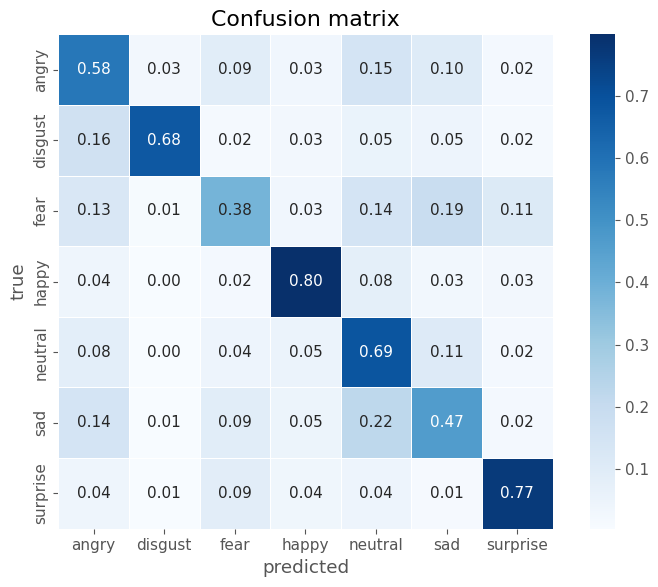

In [ ]:
train_acc_d, _ = evaluate(model_deep_cnn, X_train, y_train)
val_acc_d, _   = evaluate(model_deep_cnn, X_val, y_val)
test_acc_d, y_pred_d = evaluate(model_deep_cnn, X_test, y_test)

print(f'Best params: {best_c}')
print(f'Train accuracy: {train_acc_d*100:.2f}%')
print(f'Val accuracy:   {val_acc_d*100:.2f}%')
print(f'Test accuracy:  {test_acc_d*100:.2f}%')

results_deep = {'name': 'Deep CNN (5 layers)', 'params': best_c,
                'train_acc': train_acc_d*100, 'val_acc': val_acc_d*100, 'test_acc': test_acc_d*100}

print_confusion_matrix(y_test.cpu(), y_pred_d, EMOTION_CLASSES, normalize=True)
plot_confusion_matrix(y_test.cpu(), y_pred_d, EMOTION_CLASSES, normalize=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבלבול וסיכום משימה 3:</p>
<ul>
<li>הדיוק הסופי: 74.62 אחוז על האימון, 62.39 אחוז על הולידציה ו-62.83 אחוז על המבחן — עקביות גבוהה בין ולידציה למבחן מעידה על הכללה טובה</li>
<li>happy (80 אחוז), surprise (77 אחוז) ו-disgust (68 אחוז) זוהו הכי טוב — disgust קפץ מ-37 אחוז ב-baseline ל-68 אחוז, שיפור דרמטי בזכות שקלול המחלקות</li>
<li>fear (38 אחוז) ו-sad (47 אחוז) עדיין הקשות ביותר; fear מתבלבלת בעיקר עם sad (19 אחוז) ו-angry (13 אחוז), ו-sad מתבלבלת עם neutral (22 אחוז)</li>
<li>שיפור כולל לעומת ה-baseline: מ-50.77 אחוז ל-62.83 אחוז על המבחן — עלייה של כ-12 נקודות אחוז, בזכות העומק, הרגולריזציה ושקלול המחלקות</li>
<li>הפער בין אימון לולידציה ירד מ-~20 נקודות ב-baseline לכ-12 נקודות — הרגולריזציה הצליחה לצמצם משמעותית את ה-overfitting</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס 1 — Transfer Learning: ResNet18 מאומן מראש על ImageNet:</p>
<ul>
<li>ResNet18 הוא רשת קונבולוציה (CNN) עם חיבורי דילוג (residual), לא טרנספורמר — כאן משתמשים בה כשהיא כבר אומנה על ImageNet ומתאימים אותה לזיהוי רגשות</li>
<li>הקלט האפור (1, 48, 48) מוכפל ל-3 ערוצים, כי הרשת מצפה ל-RGB</li>
<li>ה-stem המקורי (conv 7×7 stride-2 ו-maxpool, מיועד ל-224) מוחלף ב-stem לתמונות קטנות (conv 3×3 stride-1 בלי maxpool) ששומר על הרזולוציה של 48px</li>
<li>שכבת הסיווג הוחלפה ב-Dropout ושכבה מלאה ל-7 קטגוריות, ובוצע fine-tune של כל הרשת בקצב למידה נמוך</li>
<li>אותם מנגנונים כמו ב-Deep CNN: class weights, augmentation, שמירת המשקלים הטובים ביותר ועצירה מוקדמת</li>
</ul>
</div>

In [ ]:
X_train = data_dict['X_train'].float(); y_train = data_dict['y_train']
X_val   = data_dict['X_val'].float();   y_val   = data_dict['y_val']
X_test  = data_dict['X_test'].float();  y_test  = data_dict['y_test']
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

counts = torch.bincount(y_train, minlength=7).float()
class_weights = counts.sum() / (len(counts) * counts)
print('class weights:', class_weights.detach().cpu().numpy().round(2))

Train: torch.Size([21533, 1, 48, 48]) | Val: torch.Size([7179, 1, 48, 48]) | Test: torch.Size([7178, 1, 48, 48])
class weights: [1.03 9.41 1.   0.57 0.83 0.85 1.29]


In [ ]:
model_pretrained_resnet18 = PretrainedFER(backbone='resnet18', num_classes=7, img_size=48,
                                 pretrained=True, freeze_backbone=False, dropout=0.4)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון המודל המאומן-מראש:</p>
<ul>
<li>ה-loss משוקלל לפי תדירות המחלקות (class weights) כדי לפצות על חוסר האיזון</li>
<li>קצב למידה נמוך (3e-4) כי המשקלים כבר מאומנים וצריך רק לכוונן אותם בעדינות</li>
<li>עצירה מוקדמת — אם הולידציה לא משתפרת 10 epochs רצופים, האימון נעצר</li>
<li>שמירת המשקלים של ה-epoch הטוב ביותר והצגת גרפי loss ו-accuracy</li>
</ul>
</div>

Epoch   1/100 | loss: 1.9877 | train: 44.13% | val: 41.76%  <- NEW BEST
Epoch   2/100 | loss: 1.7387 | train: 55.96% | val: 52.81%  <- NEW BEST
Epoch   3/100 | loss: 1.6187 | train: 61.45% | val: 57.92%  <- NEW BEST
Epoch   4/100 | loss: 1.5370 | train: 62.30% | val: 58.50%  <- NEW BEST
Epoch   5/100 | loss: 1.4768 | train: 62.10% | val: 56.26%
Epoch   6/100 | loss: 1.4212 | train: 65.10% | val: 58.45%
Epoch   7/100 | loss: 1.3812 | train: 67.93% | val: 59.24%  <- NEW BEST
Epoch   8/100 | loss: 1.3448 | train: 69.74% | val: 60.96%  <- NEW BEST
Epoch   9/100 | loss: 1.3038 | train: 71.95% | val: 61.67%  <- NEW BEST
Epoch  10/100 | loss: 1.2636 | train: 76.40% | val: 64.94%  <- NEW BEST
Epoch  11/100 | loss: 1.2313 | train: 75.90% | val: 64.15%
Epoch  12/100 | loss: 1.1960 | train: 80.48% | val: 65.68%  <- NEW BEST
Epoch  13/100 | loss: 1.1640 | train: 79.67% | val: 62.40%
Epoch  14/100 | loss: 1.1333 | train: 83.83% | val: 65.47%
Epoch  15/100 | loss: 1.1035 | train: 84.48% | val: 64.94

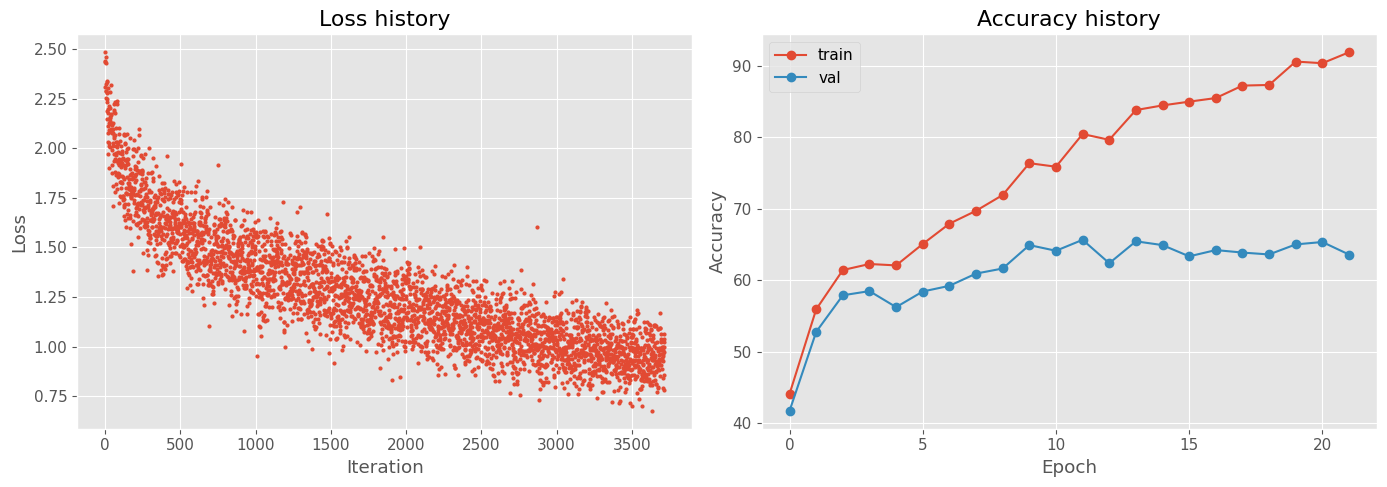

In [ ]:
stats_resnet18 = train_pretrained(model_pretrained_resnet18, X_train, y_train, X_val, y_val,
                                  lr=3e-4,
                                  weight_decay=1e-4,
                                  batch_size=128,
                                  warmup_epochs=3,
                                  num_epochs=100, augment=True, patience=10,
                                  seed=SEED, verbose=True, class_weights=class_weights)

print(f"\nBest val: {stats_resnet18['best_val_acc']:.2f}% at epoch {stats_resnet18['best_epoch']}")
plot_stats(stats_resnet18)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרפי האימון:</p>
<ul>
<li>גרף ה-loss: יורד במהירות מ-~2.0 לכ-0.9 — הרשת המאומנת-מראש מתכנסת מהר כבר מה-epochs הראשונים, יתרון בולט של transfer learning</li>
<li>גרף ה-accuracy: דיוק האימון מטפס במהירות לכ-92 אחוז, בעוד הולידציה מגיעה ל-65.68 אחוז (epoch 12) ומתייצבת סביב 63-65 אחוז</li>
<li>הפער הגדול בין האימון לולידציה מצביע על overfitting — צפוי ב-fine-tune של רשת בעלת קיבולת גבוהה על דאטה קטן; ה-best-val snapshot שומר את המשקלים שמכלילים הכי טוב</li>
<li>העצירה המוקדמת פעלה ב-epoch 22 (10 epochs ללא שיפור מאז epoch 12) והמשקלים של epoch 12 הוחזרו</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה סופית — בודקים את המודל על שלוש הקבוצות, שומרים את התוצאות להשוואה בין כל המודלים, ומציגים את מטריצת הבלבול על קבוצת המבחן.</p>
</div>

Train accuracy (ResNet18): 80.47%
Val accuracy (ResNet18):   65.68%
Test accuracy (ResNet18):  66.24%

--- Confusion Matrix (Text Table) ---
True \ Pred         angry   disgust      fear     happy   neutral       sad  surprise
-------------------------------------------------------------------------------------
angry                0.53      0.05      0.07      0.05      0.13      0.14      0.02
disgust              0.12      0.70      0.04      0.05      0.05      0.05      0.01
fear                 0.09      0.03      0.39      0.05      0.13      0.23      0.08
happy                0.01      0.01      0.01      0.88      0.05      0.02      0.02
neutral              0.04      0.01      0.03      0.06      0.68      0.16      0.01
sad                  0.08      0.02      0.09      0.05      0.19      0.56      0.02
surprise             0.03      0.01      0.05      0.06      0.04      0.02      0.79
-------------------------------------------------------------------------------------

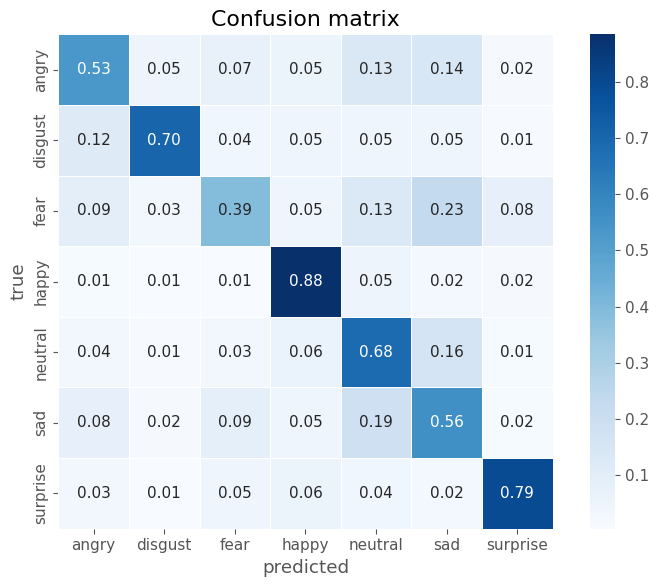

In [ ]:
train_acc_r18, _ = evaluate(model_pretrained_resnet18, X_train, y_train)
val_acc_r18, _   = evaluate(model_pretrained_resnet18, X_val, y_val)
test_acc_r18, y_pred_r18 = evaluate(model_pretrained_resnet18, X_test, y_test)

print(f'Train accuracy (ResNet18): {train_acc_r18*100:.2f}%')
print(f'Val accuracy (ResNet18):   {val_acc_r18*100:.2f}%')
print(f'Test accuracy (ResNet18):  {test_acc_r18*100:.2f}%')

results_pretrained_resnet18 = {'name': 'ResNet18 (transfer)', 'params': {'backbone': 'resnet18', 'lr': 3e-4, 'batch_size': 128},
                      'train_acc': train_acc_r18*100, 'val_acc': val_acc_r18*100, 'test_acc': test_acc_r18*100}

print_confusion_matrix(y_test.cpu(), y_pred_r18, EMOTION_CLASSES, normalize=True)
plot_confusion_matrix(y_test.cpu(), y_pred_r18, EMOTION_CLASSES, normalize=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבלבול וסיכום בונוס 1:</p>
<ul>
<li>הדיוק הסופי: 80.47 אחוז על האימון, 65.68 אחוז על הולידציה ו-66.24 אחוז על המבחן — מעל ה-Deep CNN וברמת האדם המוערכת (~65 אחוז)</li>
<li>happy (88 אחוז), surprise (79 אחוז) ו-disgust (70 אחוז) זוהו הכי טוב — disgust שומר על דיוק גבוה בזכות השילוב של transfer ו-class weights</li>
<li>neutral (68 אחוז), sad (56 אחוז) ו-angry (53 אחוז) ברמה בינונית — sad השתפר לעומת ה-Deep CNN (47 אחוז)</li>
<li>fear (39 אחוז) נותרה החלשה ביותר ומתבלבלת בעיקר עם sad (23 אחוז) ו-neutral (13 אחוז) — הקושי האינהרנטי של המחלקה</li>
<li>קיים overfitting (פער train-test של ~14 אחוז), אך הולידציה והמבחן צמודים מאוד (65.68 מול 66.24) — הכללה יציבה, והוכחה שפיצ'רים מ-ImageNet מועברים היטב גם לפנים אפורות 48px</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס 2 — Transfer Learning: Swin-T (Swin Transformer) מאומן מראש על ImageNet:</p>
<ul>
<li>Swin-T הוא טרנספורמר ראייה עם attention בחלונות (windowed), לא CNN — המודל הטרנספורמרי היחיד בפרויקט, מאומן מראש ומותאם לזיהוי רגשות</li>
<li>הקלט האפור (1, 48, 48) מוכפל ל-3 ערוצים ומוגדל ל-224×224 (הגודל שהרשת מצפה לו)</li>
<li>שכבת הסיווג הוחלפה ב-Dropout ושכבה מלאה ל-7 קטגוריות, ובוצע fine-tune של כל הרשת בקצב למידה נמוך מאוד (5e-5)</li>
<li>אותם מנגנונים כמו בשאר המודלים: class weights, augmentation, שמירת המשקלים הטובים ביותר ועצירה מוקדמת</li>
</ul>
</div>

In [ ]:
X_train = data_dict['X_train'].float(); y_train = data_dict['y_train']
X_val   = data_dict['X_val'].float();   y_val   = data_dict['y_val']
X_test  = data_dict['X_test'].float();  y_test  = data_dict['y_test']
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

counts = torch.bincount(y_train, minlength=7).float()
class_weights = counts.sum() / (len(counts) * counts)
print('class weights:', class_weights.detach().cpu().numpy().round(2))

Train: torch.Size([21533, 1, 48, 48]) | Val: torch.Size([7179, 1, 48, 48]) | Test: torch.Size([7178, 1, 48, 48])
class weights: [1.03 9.41 1.   0.57 0.83 0.85 1.29]


In [ ]:
model_pretrained_swin = PretrainedFER(backbone='swin_t', num_classes=7, img_size=224,
                                      pretrained=True, freeze_backbone=False, dropout=0.4)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון ה-Swin-T המאומן-מראש:</p>
<ul>
<li>ה-loss משוקלל לפי תדירות המחלקות (class weights) כדי לפצות על חוסר האיזון</li>
<li>קצב למידה נמוך מאוד (5e-5) ו-batch קטן (32), כי התמונות מוגדלות ל-224 והרשת כבדה</li>
<li>עצירה מוקדמת (patience=8) ושמירת המשקלים של ה-epoch הטוב ביותר</li>
<li>הצגת גרפי loss ו-accuracy לאורך האימון</li>
</ul>
</div>

Epoch   1/40 | loss: 2.0235 | train: 44.89% | val: 44.05%  <- NEW BEST
Epoch   2/40 | loss: 1.8041 | train: 55.32% | val: 54.24%  <- NEW BEST
Epoch   3/40 | loss: 1.6866 | train: 57.51% | val: 55.68%  <- NEW BEST
Epoch   4/40 | loss: 1.6022 | train: 61.91% | val: 58.77%  <- NEW BEST
Epoch   5/40 | loss: 1.5406 | train: 67.72% | val: 63.59%  <- NEW BEST
Epoch   6/40 | loss: 1.5048 | train: 67.40% | val: 62.42%
Epoch   7/40 | loss: 1.4606 | train: 70.44% | val: 64.73%  <- NEW BEST
Epoch   8/40 | loss: 1.4251 | train: 71.86% | val: 65.86%  <- NEW BEST
Epoch   9/40 | loss: 1.4070 | train: 72.24% | val: 65.13%
Epoch  10/40 | loss: 1.3768 | train: 75.77% | val: 66.64%  <- NEW BEST
Epoch  11/40 | loss: 1.3418 | train: 77.01% | val: 67.01%  <- NEW BEST
Epoch  12/40 | loss: 1.3114 | train: 78.68% | val: 67.68%  <- NEW BEST
Epoch  13/40 | loss: 1.2886 | train: 80.41% | val: 67.79%  <- NEW BEST
Epoch  14/40 | loss: 1.2637 | train: 80.63% | val: 67.35%
Epoch  15/40 | loss: 1.2380 | train: 82.80% |

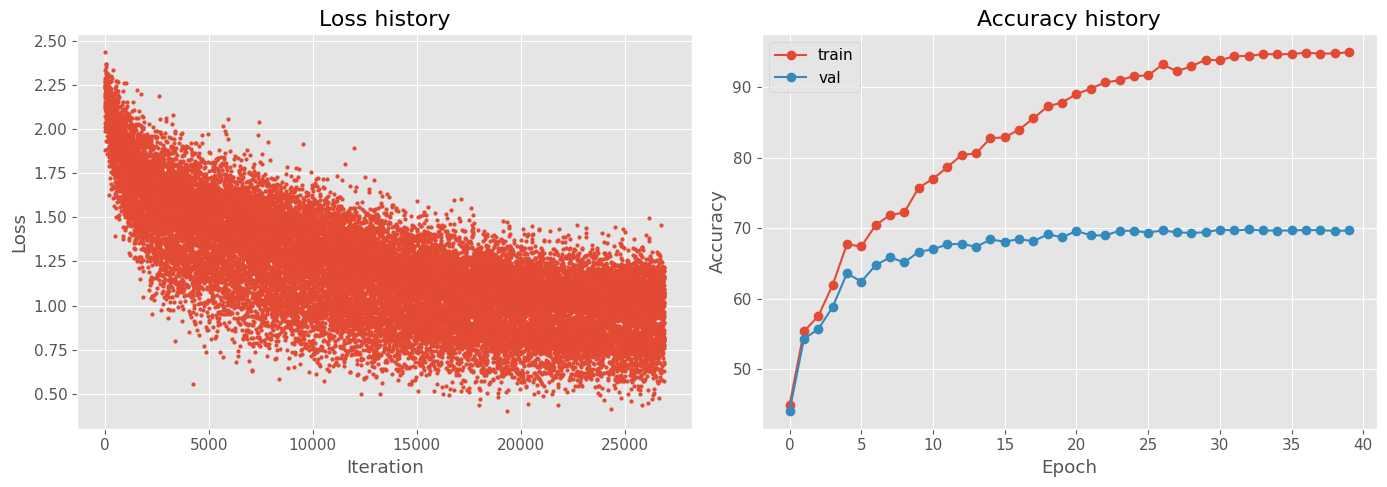

In [ ]:
stats_swin = train_pretrained(model_pretrained_swin, X_train, y_train, X_val, y_val,
                              lr=5e-5,
                              weight_decay=1e-4,
                              batch_size=32,
                              warmup_epochs=3,
                              num_epochs=40, augment=True, patience=8,
                              seed=SEED, verbose=True, class_weights=class_weights)

print(f"\nBest val: {stats_swin['best_val_acc']:.2f}% at epoch {stats_swin['best_epoch']}")
plot_stats(stats_swin)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרפי האימון:</p>
<ul>
<li>גרף ה-loss: יורד מ-~2.0 לכ-1.0 — הטרנספורמר המאומן-מראש מתכנס יפה, אם כי לאט יותר מ-ResNet בשל הרזולוציה הגבוהה (224) והמודל הכבד</li>
<li>גרף ה-accuracy: דיוק האימון מטפס לכ-95 אחוז, בעוד הולידציה מגיעה ל-69.81 אחוז (epoch 33) ומתייצבת סביב 69-70 אחוז</li>
<li>הפער בין האימון לולידציה (~25 אחוז) מצביע על overfitting — צפוי ב-fine-tune של טרנספורמר גדול על דאטה קטן; ה-best-val snapshot שומר את המשקלים הטובים ביותר</li>
<li>האימון רץ את כל 40 ה-epochs (העצירה המוקדמת לא הופעלה), והמשקלים של epoch 33 (69.81 אחוז) הוחזרו</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערכה סופית — בודקים את ה-Swin-T על שלוש הקבוצות, שומרים את התוצאות להשוואה בין כל המודלים, ומציגים את מטריצת הבלבול על קבוצת המבחן.</p>
</div>

Train accuracy (Swin-T): 94.51%
Val accuracy (Swin-T):   69.81%
Test accuracy (Swin-T):  69.70%

--- Confusion Matrix (Text Table) ---
True \ Pred         angry   disgust      fear     happy   neutral       sad  surprise
-------------------------------------------------------------------------------------
angry                0.62      0.04      0.10      0.03      0.09      0.12      0.01
disgust              0.13      0.72      0.04      0.02      0.05      0.04      0.02
fear                 0.11      0.02      0.55      0.01      0.10      0.15      0.06
happy                0.02      0.00      0.02      0.86      0.06      0.02      0.02
neutral              0.05      0.02      0.06      0.04      0.71      0.12      0.01
sad                  0.09      0.03      0.13      0.02      0.18      0.55      0.01
surprise             0.03      0.00      0.08      0.03      0.02      0.01      0.83
-------------------------------------------------------------------------------------



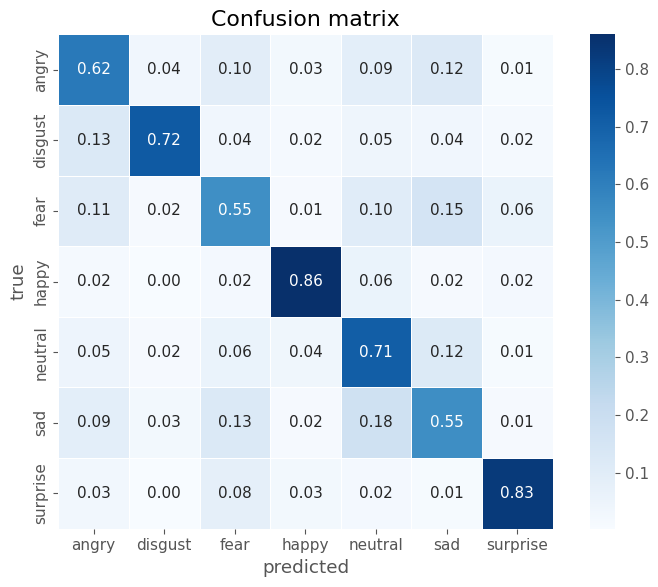

In [ ]:
train_acc_swin, _ = evaluate(model_pretrained_swin, X_train, y_train)
val_acc_swin, _   = evaluate(model_pretrained_swin, X_val, y_val)
test_acc_swin, y_pred_swin = evaluate(model_pretrained_swin, X_test, y_test)

print(f'Train accuracy (Swin-T): {train_acc_swin*100:.2f}%')
print(f'Val accuracy (Swin-T):   {val_acc_swin*100:.2f}%')
print(f'Test accuracy (Swin-T):  {test_acc_swin*100:.2f}%')

results_pretrained_swin = {'name': 'Swin-T (transfer)', 'params': {'backbone': 'swin_t', 'lr': 1e-4, 'batch_size': 64},
                  'train_acc': train_acc_swin*100, 'val_acc': val_acc_swin*100, 'test_acc': test_acc_swin*100}

print_confusion_matrix(y_test.cpu(), y_pred_swin, EMOTION_CLASSES, normalize=True)
plot_confusion_matrix(y_test.cpu(), y_pred_swin, EMOTION_CLASSES, normalize=True)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבלבול וסיכום בונוס 2:</p>
<ul>
<li>הדיוק הסופי: 94.51 אחוז על האימון, 69.81 אחוז על הולידציה ו-69.70 אחוז על המבחן — התוצאה הטובה ביותר בכל הפרויקט, מעל ResNet (66 אחוז), Deep CNN (63 אחוז) ורמת האדם המוערכת (~65 אחוז), ומתקרבת ל-SOTA (73-76 אחוז)</li>
<li>happy (86 אחוז), surprise (83 אחוז) ו-disgust (72 אחוז) זוהו הכי טוב</li>
<li>neutral (71 אחוז) ו-angry (62 אחוז) השתפרו משמעותית לעומת שאר המודלים</li>
<li>fear (55 אחוז) ו-sad (55 אחוז) עדיין הקשות ביותר, אך עם שיפור דרמטי: fear עלה מ-39 אחוז ב-ResNet ל-55 אחוז — השיפור הגדול ביותר בכל המודלים</li>
<li>קיים overfitting (פער train-test של ~25 אחוז), אך הולידציה והמבחן כמעט זהים (69.81 מול 69.70) — הכללה יציבה מאוד. המסקנה: טרנספורמר מאומן-מראש מנצח, ומוכיח שטרנספורמרים עובדים מצוין על הבעיה דווקא כשהם מאומנים מראש</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טבלאות וגרפי סיכום</p>
</div>

In [ ]:
meta = {'results_svm':                 ('Linear',      'from scratch'),
        'results_2layer':              ('CNN',         'from scratch'),
        'results_deep':                ('CNN',         'from scratch'),
        'results_pretrained_resnet18': ('CNN',         'transfer'),
        'results_pretrained_swin':     ('Transformer', 'transfer'),}

rows = []
for n, (typ, mode) in meta.items():
    if n in globals():
        r = globals()[n]
        rows.append({'Model':     r['name'],
                     'Type':      typ,
                     'Training':  mode,
                     'Train (%)': round(r['train_acc'], 2),
                     'Val (%)':   round(r['val_acc'], 2),
                     'Test (%)':  round(r['test_acc'], 2),})

df_models = pd.DataFrame(rows).sort_values('Test (%)', ascending=False).reset_index(drop=True)
df_models

,Model,Type,Training,Train (%),Val (%),Test (%)
0,Swin-T (transfer),Transformer,transfer,94.51,69.81,69.70
1,ResNet18 (transfer),CNN,transfer,80.47,65.68,66.24
2,Deep CNN (5 layers),CNN,from scratch,74.62,62.39,62.83
3,Simple CNN (2 layers),CNN,from scratch,71.41,51.19,50.77
4,Linear SVM,Linear,from scratch,38.68,35.85,37.32


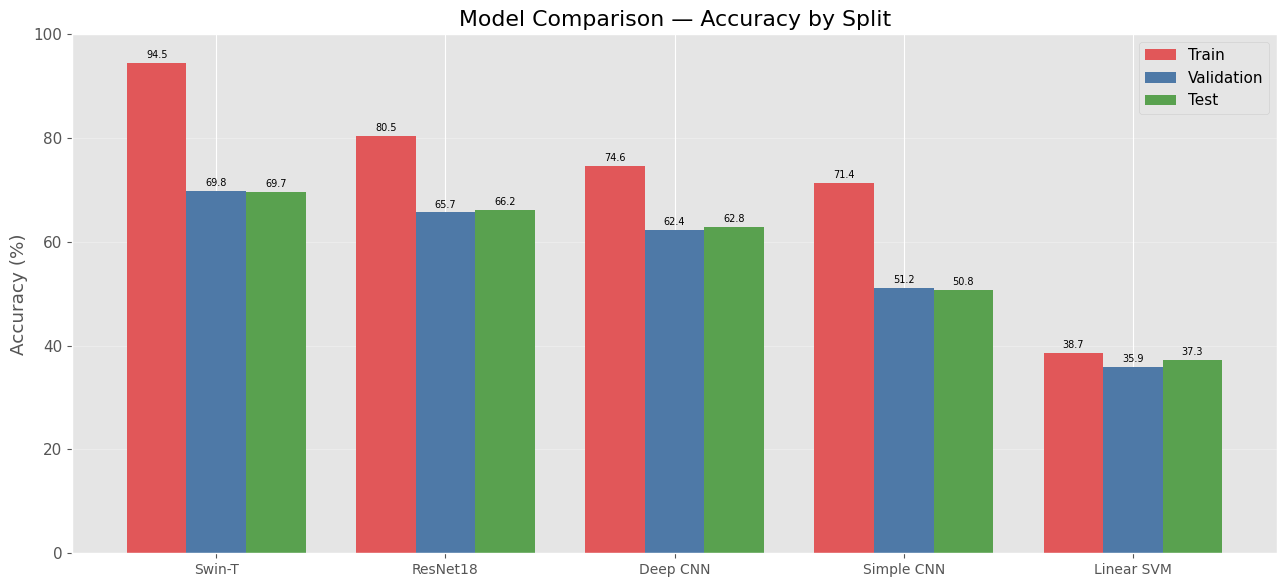

In [ ]:
names = df_models['Model'].tolist()
train = df_models['Train (%)'].values
val   = df_models['Val (%)'].values
test  = df_models['Test (%)'].values

x = np.arange(len(names)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w, train, w, label='Train',      color='#e15759')
b2 = ax.bar(x,     val,   w, label='Validation', color='#4e79a7')
b3 = ax.bar(x + w, test,  w, label='Test',       color='#59a14f')
for b in (b1, b2, b3):
    ax.bar_label(b, fmt='%.1f', fontsize=7, padding=2)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('Model Comparison — Accuracy by Split')
ax.set_xticks(x)
ax.set_xticklabels([n.split(' (')[0] for n in names], rotation=0, fontsize=10)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח טבלת וגרף ההשוואה הכללית (דיוק לפי split):</p>
<ul>
<li>Swin-T (Transformer, transfer) — Train 94.5% / Val 69.8% / Test 69.7% — המודל החזק ביותר בפרויקט. טרנספורמר מאומן מראש על ImageNet.</li>
<li>ResNet18 (CNN, transfer) — Train 80.5% / Val 65.7% / Test 66.2% — מודל transfer learning שני בטבלה, עוקף בבירור את כל המודלים שאומנו מאפס.</li>
<li>Deep CNN (5 blocks, from scratch) — Train 74.6% / Val 62.4% / Test 62.8% — ההישג הבולט של הפרויקט. מודל עמוק שאומן מאפס הגיע למרחק של כ-7 נקודות בלבד מה-Swin-T, בזכות ארכיטקטורה טובה, רגולריזציה חזקה ו-augmentation.</li>
<li>Simple CNN (2 blocks, from scratch) — Train 71.4% / Val 51.2% / Test 50.8% — מודל בסיסי עם overfitting משמעותי (פער של כ-20% בין Train ל-Test).</li>
<li>Linear SVM — Train 38.7% / Val 35.9% / Test 37.3% — בסיס לינארי פשוט — לוכד רק דפוסים בסיסיים.</li>
<li>מסקנה רוחבית: הדיוק עלה בצורה עקבית עם רמת המורכבות של המודל — מ-37.3% (SVM) עד 69.7% (Swin-T).
יחד עם זאת, ככל שהמודל מורכב ומשתפר יותר, עולה גם רמת ה-overfitting (פער גדול יותר בין Train ל-Val/Test). למרות זאת, בכל המודלים ה-Val וה-Test קרובים זה לזה — עדות להכללה טובה יחסית.</li>
</ul>
<hr>
</div>

In [ ]:
def to_np(a):
    return a.cpu().numpy() if hasattr(a, 'cpu') else np.asarray(a)

pred_specs = [('Linear SVM', 'y_pred_svm'), ('Simple CNN', 'y_pred_s'),
              ('Deep CNN', 'y_pred_d'), ('ResNet18', 'y_pred_r18'),
              ('Swin-T', 'y_pred_swin')]
pred_specs = [(nm, v) for nm, v in pred_specs if v in globals()]

y_true = to_np(y_test)
rows = {}
for nm, v in pred_specs:
    yp = to_np(globals()[v])
    rows[nm] = {EMOTION_CLASSES[c]: round((yp[y_true == c] == c).mean() * 100, 1)
                for c in range(len(EMOTION_CLASSES))}
    rows[nm]['Overall'] = round((yp == y_true).mean() * 100, 1)

df_class = pd.DataFrame(rows).T[EMOTION_CLASSES + ['Overall']]
df_class

,angry,disgust,fear,happy,neutral,sad,surprise,Overall
Linear SVM,17.0,4.5,14.2,57.9,37.8,31.0,58.5,37.3
Simple CNN,36.8,36.9,26.7,75.9,50.2,35.9,67.9,50.8
Deep CNN,58.0,67.6,38.3,80.0,68.8,46.7,76.8,62.8
ResNet18,53.2,70.3,39.2,88.4,68.2,56.0,79.3,66.2
Swin-T,62.2,72.1,54.7,86.0,70.6,54.9,82.6,69.7


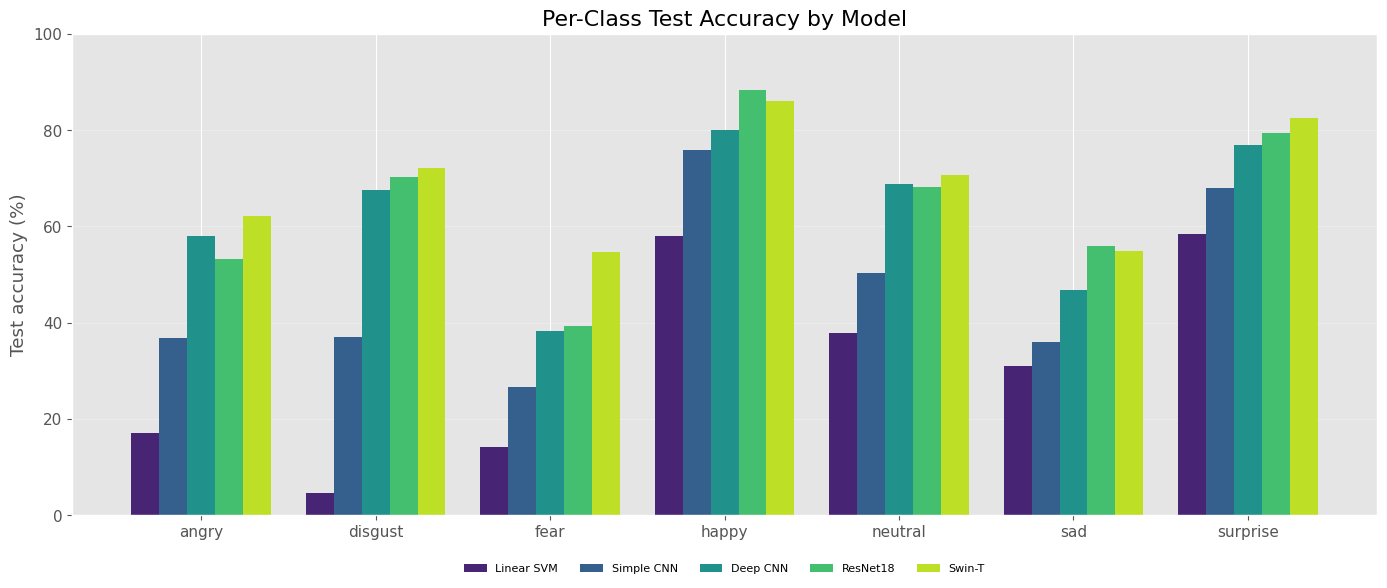

In [ ]:
emotions    = [c for c in df_class.columns if c != 'Overall']
model_names = df_class.index.tolist()
data        = df_class[emotions].values

n_models = len(model_names)
x = np.arange(len(emotions)); w = 0.8 / n_models
colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_models))

fig, ax = plt.subplots(figsize=(14, 6))
for m in range(n_models):
    ax.bar(x + (m - (n_models - 1) / 2) * w, data[m], w,
           label=model_names[m], color=colors[m])
ax.set_ylabel('Test accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('Per-Class Test Accuracy by Model')
ax.set_xticks(x); ax.set_xticklabels(emotions)
ax.legend(ncol=n_models, loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fontsize=8, frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח טבלת וגרף הדיוק לכל רגש (test):</p>
<ul>
<li>happy / surprise — הקלים ביותר בכל המודלים (הבעות בולטות וברורות); happy עולה מ-58% ב-SVM ל-86% ב-Swin.</li>
<li>disgust — ממחיש את אפקט שקלול המחלקות: מ-4.5% ב-SVM ל-72% ב-Swin, למרות שהיא רק ~1.5% מהדאטה.</li>
<li>fear / sad — הקשים ביותר בכל המודלים; חופפים סמנטית ומתבלבלים זה עם זה ועם neutral. Swin שיפר את fear הכי הרבה — מ-14% ל-55%.</li>
<li>neutral / angry — רמה בינונית; משתפרים בהתמדה עד Swin (neutral 71%, angry 62%).</li>
<li>מסקנה רוחבית: כמעט בכל רגש הדיוק עולה באופן מונוטוני מ-SVM ועד Swin — המודלים החזקים משתפרים על פני כל הקטגוריות, לא רק בממוצע.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום כולל:</p>
<ul>
<li>התקדמות שיטתית — בדקנו חמישה מודלים בסדר עולה של מורכבות. הדיוק על מבחן עלה מ-37.3% (Linear SVM) ל-69.7% (Swin-T) — שיפור של יותר מ-32%.</li>
<li>Deep CNN מאפס — ההישג הבולט — ה-Deep CNN שפיתחנו מאפס (ללא שום weights חיצוניים) הגיע ל-62.8% דיוק — רק כ-7 נקודות אחוז מתחת ל-Swin-T שנהנה ממיליוני תמונות ImageNet. זה מדגים בצורה מרשימה שארכיטקטורה טובה, רגולריזציה חזקה, Data Augmentation על GPU ושקלול מחלקות יכולים להביא ביצועים גבוהים גם על דאטה מוגבל.</li>
<li>Transfer Learning — כצפוי, Transfer Learning (ResNet18 ו-Swin-T) היה המנוף החזק ביותר והביא את התוצאות הגבוהות ביותר.</li>
<li>מגבלות מערך הנתונים — הדאטה עצמו מציב תקרה משמעותית: רזולוציה נמוכה (48×48), תוויות רועשות והבעות דו-משמעיות (בעיקר fear/sad שמתבלבלים עם neutral). לכן גם המודל הטוב ביותר מתייצב סביב 70%.</li>
<li>טיפול בחוסר איזון — שקלול מחלקות שיפר דרמטית את זיהוי ה-disgust (מהרמה הנמוכה ביותר ל-72% ב-Swin). עם זאת, fear ו-sad נשארו האתגר הקשה ביותר.</li>
<li>הכללה ויציבות — בכל המודלים קיבלנו הכללה טובה (ולידציה ≈ test) בזכות Grid Search, שמירת best model ורגולריזציה חזקה.</li>
</ul>
</div>